## Notebook Summary

This notebook explores various Autoencoder-based anomaly detection models for network intrusion detection, focusing on feature engineering and selection techniques. The key steps and models covered include:

1.  **Full Feature Autoencoder**: An initial autoencoder model trained on all available features to establish a baseline performance.
2.  **Algorithmic Feature Optimization**: Application of filter-based feature selection (Variance Threshold and Correlation Filter) to identify a reduced set of optimal features. This optimized feature set was then used to train another autoencoder.
3.  **Domain Knowledge Optimized Autoencoder**: A model trained on a manually selected set of features, informed by domain expertise, for comparison.
4.  **Hybrid Autoencoder**: This approach combines domain knowledge with algorithmic validation and performance-based pruning to select a highly optimized feature set. A final autoencoder model was trained and thoroughly analyzed using these hybrid features.
5. **Zer0-Day Attack Detection Expirement:**
Tests whether the hybrid autoencoder can detect UNSEEN attack types that were never present during training.
6. **Quantization:** A method where an already trained model is converted to lower precision
7.  **Baseline Models**: Several unsupervised anomaly detection algorithms (Isolation Forest, One-Class SVM, Local Outlier Factor) were implemented and evaluated using the hybrid-selected features to provide a comparative performance benchmark against the autoencoder models.
8.  **Explainability (SHAP)**: SHAP values were used to interpret the feature importance for the hybrid autoencoder, providing insights into which features contribute most to anomaly detection.
9.  **Computational Efficiency Analysis**: The training and inference efficiency, as well as model size, of the full feature and hybrid autoencoders were compared.
10.  **Attack-Type Performance Analysis**: The hybrid autoencoder's performance was analyzed across different attack types.

11. **Robustness Analysis**: The stability of the hybrid autoencoder's performance was assessed over multiple runs with different random seeds.

# FULL FEATURE AUTOENCODER

<>:83: SyntaxWarning: invalid escape sequence '\ '
<>:83: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_4612/606180225.py:83: SyntaxWarning: invalid escape sequence '\ '
  print(f"\ Input dimension: {input_dim_full} features")



 Total feature count: 42 features
   Features: ['src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_version', 'http_request_body_len', 'http_response_body_len', 'http_status_code', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice']

 Preprocessing complete: Outlier clipping + RobustScaler

 Training on 32000 normal samples
 Validation on 8000 normal samples
 Test on 42209 samples (mixed)
\ Input dimension: 42 features

 Training Autoencoder with ALL 42 features
 Autoencoder training complete

 Threshold: 0.596583 (85th percentile)
FULL FEATURE AUTOENCOD

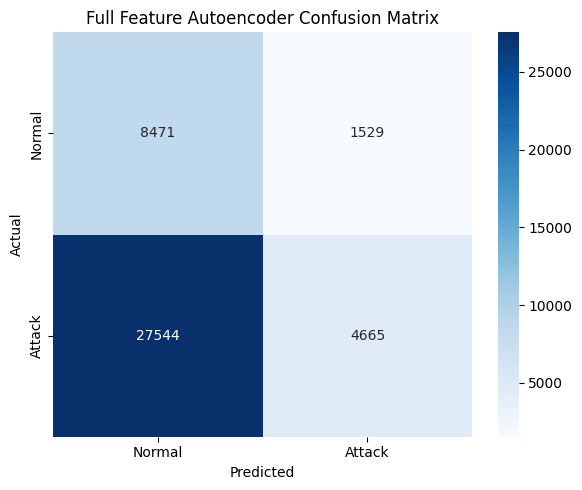

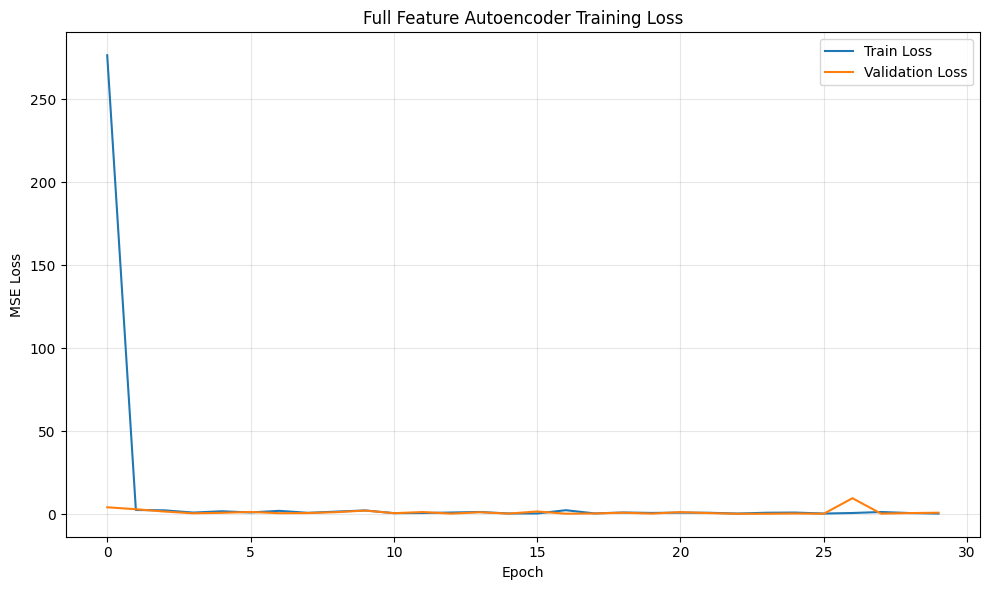

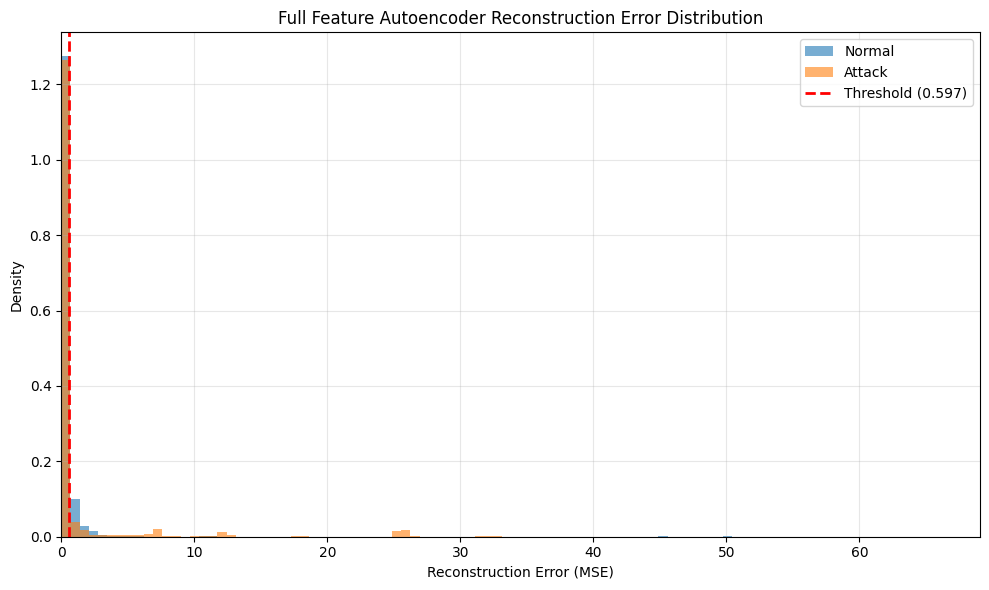


 Full feature results stored
   Features: 42
   F1-Score: 0.2429


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


# 1. LOAD DATASET

df_full = pd.read_csv('train_test_network.csv')
df_full = df_full.replace('-', np.nan)

# Fill missing
numeric_cols = df_full.select_dtypes(include=[np.number]).columns
df_full[numeric_cols] = df_full[numeric_cols].fillna(0)
categorical_cols = df_full.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if col not in ['label', 'type']:
        df_full[col] = df_full[col].fillna('unknown')

# Feature engineering
def port_category(port):
    if port <= 1023: return 0
    elif port <= 49151: return 1
    else: return 2
df_full['dst_port'] = df_full['dst_port'].apply(port_category)

# Encode categoricals
df_full['proto'] = LabelEncoder().fit_transform(df_full['proto'])
df_full['conn_state'] = LabelEncoder().fit_transform(df_full['conn_state'])

# Prepare features/target (KEEP ALL FEATURES)
X_full = df_full.drop(columns=['label', 'type'], errors='ignore')
y_full = df_full['label']

# Encode any remaining categorical columns in X_full
for col in X_full.select_dtypes(include=['object']).columns:
    X_full[col] = LabelEncoder().fit_transform(X_full[col])

print(f"\n Total feature count: {X_full.shape[1]} features")
print(f"   Features: {list(X_full.columns)}")


# 2. PREPROCESSING
# Clip outliers
for col in X_full.columns:
    lower = X_full[col].quantile(0.01)
    upper = X_full[col].quantile(0.99)
    X_full[col] = X_full[col].clip(lower, upper)

# Scale
scaler_full = RobustScaler()
X_full_scaled = scaler_full.fit_transform(X_full)

print(f"\n Preprocessing complete: Outlier clipping + RobustScaler")


# 3. SPLIT DATA

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full_scaled, y_full, test_size=0.2, random_state=42, stratify=y_full
)

#  normal samples only for unsupervised training
X_train_normal_full = pd.DataFrame(X_train_full[y_train_full == 0]) # Convert to DataFrame
X_val_normal_full = X_train_normal_full.sample(frac=0.2, random_state=42)
X_train_final_full = X_train_normal_full.drop(X_val_normal_full.index)

print(f"\n Training on {len(X_train_final_full)} normal samples")
print(f" Validation on {len(X_val_normal_full)} normal samples")
print(f" Test on {len(X_test_full)} samples (mixed)")


# 4. BUILD AUTOENCODER

input_dim_full = X_train_final_full.shape[1]
print(f"\ Input dimension: {input_dim_full} features")

input_layer = Input(shape=(input_dim_full,))
encoded = Dense(64, activation="relu")(input_layer)
encoded = Dense(32, activation="relu")(encoded)
encoded = Dense(16, activation="relu")(encoded)
decoded = Dense(32, activation="relu")(encoded)
decoded = Dense(64, activation="relu")(decoded)
decoded = Dense(input_dim_full, activation="linear")(decoded)

autoencoder_full = Model(inputs=input_layer, outputs=decoded)
autoencoder_full.compile(optimizer='adam', loss='mse')

print(f"\n Training Autoencoder with ALL {input_dim_full} features")


# 5. TRAIN

history_full = autoencoder_full.fit(
    X_train_final_full, X_train_final_full,
    epochs=30, batch_size=64,
    validation_data=(X_val_normal_full, X_val_normal_full),
    shuffle=True, verbose=0
)
print(" Autoencoder training complete")

# 6. THRESHOLD OPTIMIZATION

val_recon_full = autoencoder_full.predict(X_val_normal_full, verbose=0)
val_mse_full = np.mean(np.power(X_val_normal_full - val_recon_full, 2), axis=1)
threshold_full = np.percentile(val_mse_full, 85)
print(f"\n Threshold: {threshold_full:.6f} (85th percentile)")


# 7. EVALUATE ON TEST SET

test_recon_full = autoencoder_full.predict(X_test_full, verbose=0)
test_mse_full = np.mean(np.power(X_test_full - test_recon_full, 2), axis=1)
y_pred_full = (test_mse_full > threshold_full).astype(int)


print("FULL FEATURE AUTOENCODER RESULTS")
print(classification_report(y_test_full, y_pred_full, target_names=['Normal', 'Attack']))

# Calculate metrics
full_f1 = f1_score(y_test_full, y_pred_full, pos_label=1)
full_roc_auc = roc_auc_score(y_test_full, test_mse_full)
full_p = precision_score(y_test_full, y_pred_full, pos_label=1)
full_r = recall_score(y_test_full, y_pred_full, pos_label=1)
full_acc = (y_pred_full == y_test_full).sum() / len(y_test_full)

print(f"\n F1-Score with {input_dim_full} features: {full_f1:.4f}")
print(f" ROC-AUC with {input_dim_full} features: {full_roc_auc:.4f}")
print(f" Precision with {input_dim_full} features: {full_p:.4f}")
print(f" Recall with {input_dim_full} features: {full_r:.4f}")
print(f" Accuracy with {input_dim_full} features: {full_acc:.4f}")


# 8. CONFUSION MATRIX

cm_full = confusion_matrix(y_test_full, y_pred_full)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_full, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Full Feature Autoencoder Confusion Matrix')
plt.tight_layout()
plt.savefig('full_feature_confusion_matrix.png', dpi=300)
plt.show()


# 9. TRAINING HISTORY
plt.figure(figsize=(10, 6))
plt.plot(history_full.history['loss'], label='Train Loss')
plt.plot(history_full.history['val_loss'], label='Validation Loss')
plt.title('Full Feature Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('full_feature_training_loss.png', dpi=300)
plt.show()


# 10. RECONSTRUCTION ERROR DISTRIBUTION

test_mse_normal_full = test_mse_full[y_test_full == 0]
test_mse_attack_full = test_mse_full[y_test_full == 1]

plt.figure(figsize=(10, 6))
max_x_full = np.percentile(test_mse_full, 99)
plt.hist(test_mse_normal_full, bins=100, alpha=0.6, label='Normal', density=True, range=(0, max_x_full))
plt.hist(test_mse_attack_full, bins=100, alpha=0.6, label='Attack', density=True, range=(0, max_x_full))
plt.axvline(x=threshold_full, color='red', linestyle='--', linewidth=2, label=f'Threshold ({threshold_full:.3f})')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Density')
plt.title('Full Feature Autoencoder Reconstruction Error Distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, max_x_full)
plt.tight_layout()
plt.savefig('full_feature_reconstruction_error.png', dpi=300)
plt.show()



# Store in results dictionary (assuming you have this from hybrid model)
if 'results' not in globals():
    results = []

results.append({
    'Model': 'Autoencoder (Full Features)',
    'Features': input_dim_full,
    'Precision': full_p,
    'Recall': full_r,
    'F1-Score': full_f1,
    'Accuracy': full_acc
})

print(f"\n Full feature results stored")
print(f"   Features: {input_dim_full}")
print(f"   F1-Score: {full_f1:.4f}")

## FEATURE OPTIMIZED MODEL: Domain Knowledge Method



 Threshold: 0.0163 
 Normal MSE mean: 0.1170
 Attack MSE mean: 0.4899

 Classification Report:
              precision    recall  f1-score   support

      Normal       0.72      0.85      0.78     10000
      Attack       0.95      0.90      0.92     32209

    accuracy                           0.89     42209
   macro avg       0.83      0.87      0.85     42209
weighted avg       0.90      0.89      0.89     42209

 ROC-AUC: 0.917

 Confusion Matrix:
[[ 8511  1489]
 [ 3358 28851]]


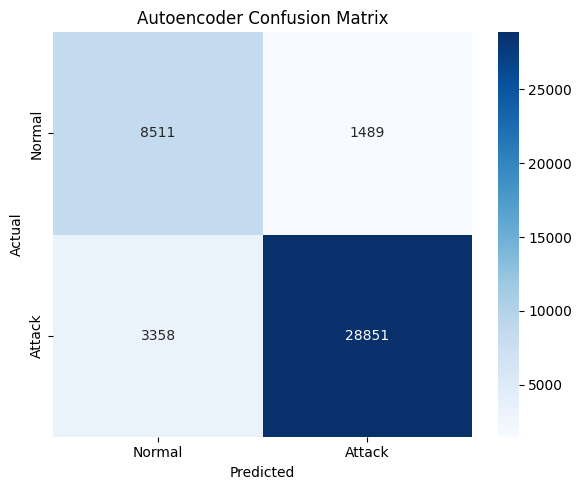

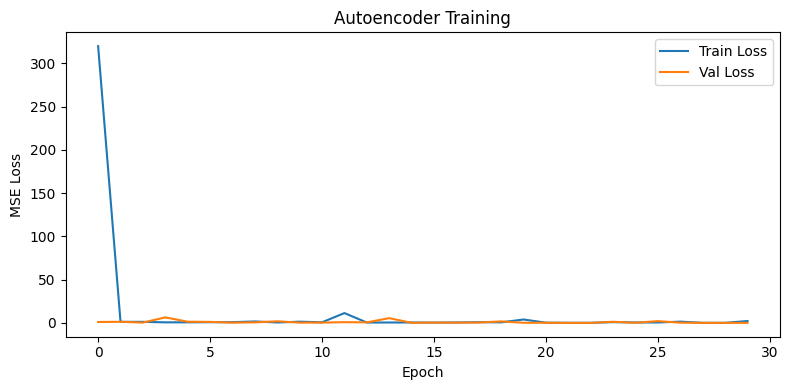

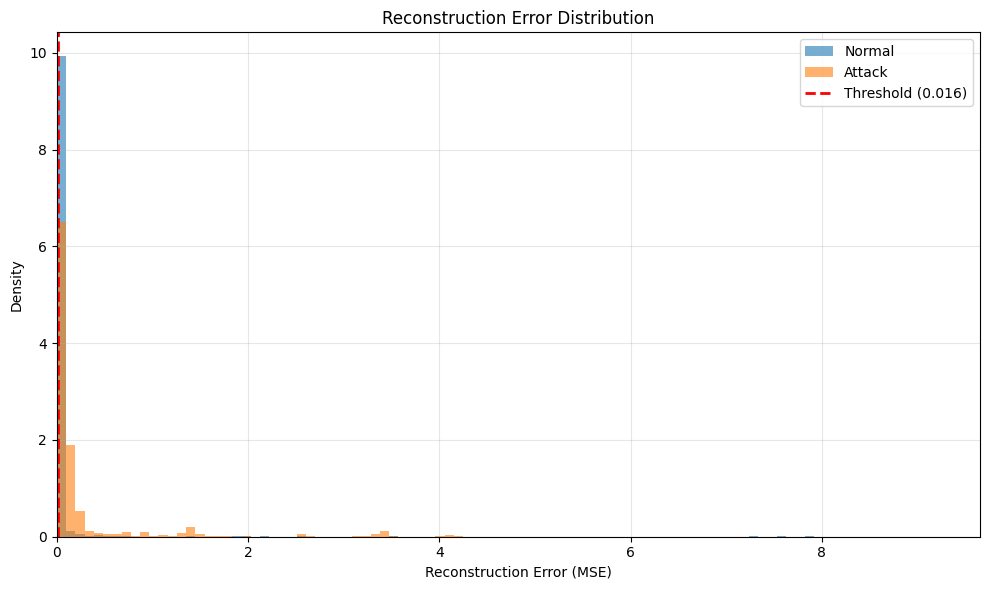

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
import matplotlib.pyplot as plt

#  LOAD & CLEAN
df = pd.read_csv('TON cleaned.csv')
df = df.replace('-', np.nan)

# Fill missing
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(0)
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if col not in ['label', 'type']:
        df[col] = df[col].fillna('unknown')

# Feature engineering
def port_category(port):
    if port <= 1023: return 0
    elif port <= 49151: return 1
    else: return 2
df['dst_port'] = df['dst_port'].apply(port_category)

# Encode
df['proto'] = LabelEncoder().fit_transform(df['proto'])
df['conn_state'] = LabelEncoder().fit_transform(df['conn_state'])


# Prepare features/target
X = df.drop(columns=['label', 'type'], errors='ignore')
y = df['label']

#  CLIP OUTLIERS
for col in X.columns:
    lower = X[col].quantile(0.01)
    upper = X[col].quantile(0.99)
    X[col] = X[col].clip(lower, upper)

# SCALE
scaler = RobustScaler()  # Changed from StandardScaler
X_scaled = scaler.fit_transform(X) # Uncommented this line


#  SPLIT: Normal for training
X_normal = X_scaled[y == 0]
X_attack = X_scaled[y == 1]

# Train/val split on NORMAL only
X_train_anom, X_val_normal = train_test_split(X_normal, test_size=0.2, random_state=42)

# Test set: keep class distribution
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# BUILD AUTOENCODER
input_dim = X_train_anom.shape[1]
input_layer = Input(shape=(input_dim,))
encoded = Dense(32, activation="relu")(input_layer)
encoded = Dense(24, activation="relu")(encoded)  # Slightly larger bottleneck
decoded = Dense(32, activation="relu")(encoded)
decoded = Dense(input_dim, activation="linear")(decoded)  # Linear output

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mse')

#TRAIN
history = autoencoder.fit(
    X_train_anom, X_train_anom,
    epochs=30, batch_size=64,
    validation_data=(X_val_normal, X_val_normal),
    shuffle=True, verbose=0
)

# SET THRESHOLD ON VALIDATION NORMAL DATA
val_recon = autoencoder.predict(X_val_normal, verbose=0)
val_mse = np.mean(np.power(X_val_normal - val_recon, 2), axis=1)
threshold = np.percentile(val_mse, 85)
print(f" Threshold: {threshold:.4f} ")

#  EVALUATE ON TEST SET
test_recon = autoencoder.predict(X_test, verbose=0)
test_mse = np.mean(np.power(X_test - test_recon, 2), axis=1)
y_pred = (test_mse > threshold).astype(int)

# Threshold OUTPUT
test_mse_normal = test_mse[y_test == 0]
test_mse_attack = test_mse[y_test == 1]
print(f" Normal MSE mean: {test_mse_normal.mean():.4f}")
print(f" Attack MSE mean: {test_mse_attack.mean():.4f}")


print("\n Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))
print(f" ROC-AUC: {roc_auc_score(y_test, test_mse):.3f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\n Confusion Matrix:\n{cm}")

# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Autoencoder Confusion Matrix')
plt.tight_layout()
plt.show()

#PLOT LOSS
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Autoencoder Training')
plt.legend()
plt.tight_layout()
plt.show()

# PLOT RECONSTRUCTION ERROR DISTRIBUTION
plt.figure(figsize=(10, 6))
max_x = np.percentile(test_mse, 99)
plt.hist(test_mse_normal, bins=100, alpha=0.6, label='Normal', density=True, range=(0, max_x))
plt.hist(test_mse_attack, bins=100, alpha=0.6, label='Attack', density=True, range=(0, max_x))
plt.axvline(x=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold ({threshold:.3f})')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Density')
plt.title('Reconstruction Error Distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, max_x)
plt.tight_layout()
plt.show()

# Feature Optimization; Filter method





 Original feature count: 42 features
 Feature names: ['src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_version', 'http_request_body_len', 'http_response_body_len', 'http_status_code', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice']

 Preprocessing complete: Outlier clipping + RobustScaler
 Train set: 168834 samples
 Test set: 42209 samples

Variance threshold: 0.01
Features removed (low variance): 19
   Removed: ['ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri

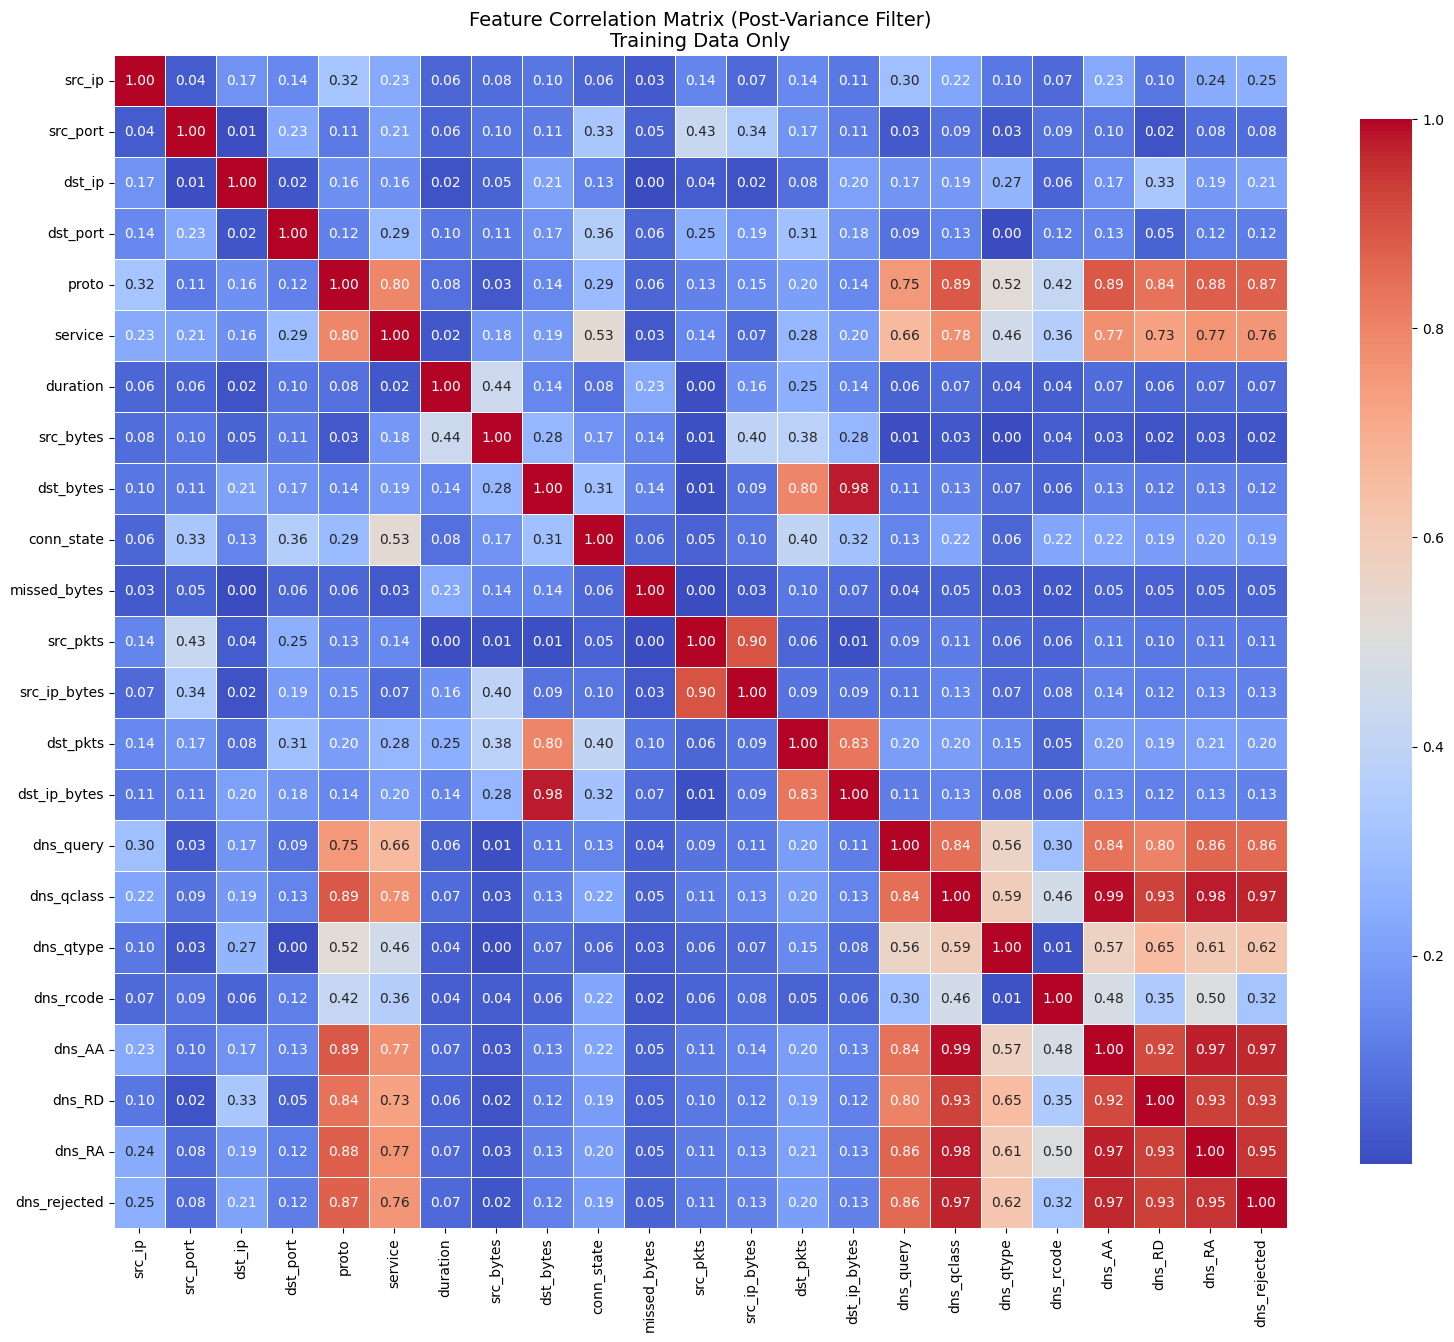


Algorithm selected: 19 features
You manually selected: 11 features

Overlap: 10 features match (90.9%) affinities

Matched features: {'src_ip_bytes', 'src_pkts', 'dst_pkts', 'conn_state', 'proto', 'src_bytes', 'duration', 'dst_bytes', 'missed_bytes', 'dst_port'}

Algorithm added (not selected): {'service', 'dns_qclass', 'dns_RD', 'dns_qtype', 'src_port', 'dns_rcode', 'dns_query', 'dst_ip', 'src_ip'}

 not selected (algorithm removed): {'dst_ip_bytes'}

  VALIDATION: 10  features algorithmically selected.

 Selected features saved to 'selected_features_algorithmic.csv'

 Selected feature matrix shape: (168834, 19)


In [ ]:

# ALGORITHMIC FEATURE OPTIMIZATION: FILTER-BASED SELECTION
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')



# 1. LOAD DATASET

df = pd.read_csv('train_test_network.csv')
df = df.replace('-', np.nan)

# Fill missing
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(0)
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if col not in ['label', 'type']:
        df[col] = df[col].fillna('unknown')

# Feature engineering (same as your pipeline)
def port_category(port):
    if port <= 1023: return 0
    elif port <= 49151: return 1
    else: return 2
df['dst_port'] = df['dst_port'].apply(port_category)

# Prepare features/target (KEEP ALL FEATURES)
X = df.drop(columns=['label', 'type'], errors='ignore')
y = df['label']

# Encode all remaining categorical columns in X
for col in X.select_dtypes(include=['object']).columns:
    X[col] = LabelEncoder().fit_transform(X[col])

print(f"\n Original feature count: {X.shape[1]} features")
print(f" Feature names: {list(X.columns)}")


# 2. PREPROCESSING
# Clip outliers (1st/99th percentile)
numeric_cols_for_clipping = X.select_dtypes(include=[np.number]).columns
for col in numeric_cols_for_clipping:
    lower = X[col].quantile(0.01)
    upper = X[col].quantile(0.99)
    X[col] = X[col].clip(lower, upper)

# Scale (RobustScaler)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for feature names
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print(f"\n Preprocessing complete: Outlier clipping + RobustScaler")

# 3. SPLIT DATA

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y, test_size=0.2, random_state=42, stratify=y
)

print(f" Train set: {X_train.shape[0]} samples")
print(f" Test set: {X_test.shape[0]} samples")


# 4. STAGE 1: VARIANCE THRESHOLD

var_threshold = 0.01  # Remove features with variance < 0.01
selector_var = VarianceThreshold(threshold=var_threshold)
selector_var.fit(X_train)

mask_variance = selector_var.get_support()
features_after_variance = X_train.columns[mask_variance]
features_removed_variance = X_train.columns[~mask_variance]

print(f"\nVariance threshold: {var_threshold}")
print(f"Features removed (low variance): {len(features_removed_variance)}")
if len(features_removed_variance) > 0:
    print(f"   Removed: {list(features_removed_variance)}")
print(f"Features remaining: {len(features_after_variance)}")
print(f"   Kept: {list(features_after_variance)}")


# 5. STAGE 2: CORRELATION FILTER

corr_threshold = 0.95  # Remove one of any pair with correlation > 0.95
corr_matrix = X_train[features_after_variance].corr().abs()

# Create upper triangle mask
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with high correlation
to_drop_corr = [column for column in upper.columns if any(upper[column] > corr_threshold)]

features_algorithm = [f for f in features_after_variance if f not in to_drop_corr]

print(f"\nCorrelation threshold: {corr_threshold}")
print(f"Features removed (high correlation): {len(to_drop_corr)}")
if len(to_drop_corr) > 0:
    print(f"   Removed: {to_drop_corr}")
print(f" Algorithm-selected features: {len(features_algorithm)}")
print(f"   Selected: {features_algorithm}")


# 6. VISUALIZE CORRELATION HEATMAP

plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True,
            cbar_kws={"shrink": .8}, linewidths=.5)
plt.title(f'Feature Correlation Matrix (Post-Variance Filter)\nTraining Data Only', fontsize=14)
plt.tight_layout()
plt.savefig('feature_correlation_heatmap.png', dpi=300, bbox_inches='tight')
print(f"\n Correlation heatmap saved as 'feature_correlation_heatmap.png'")
plt.show()


# 7. COMPARE WITH YOUR MANUAL 11 FEATURES

# Your manual  features
your_manual_features = [
    'dst_port', 'proto', 'duration', 'src_bytes', 'dst_bytes',
    'conn_state', 'missed_bytes', 'src_pkts', 'src_ip_bytes',
    'dst_pkts', 'dst_ip_bytes',
]

# Check overlap
overlap = set(features_algorithm).intersection(set(your_manual_features))
algorithm_only = set(features_algorithm) - set(your_manual_features)
manual_only = set(your_manual_features) - set(features_algorithm)

print(f"\nAlgorithm selected: {len(features_algorithm)} features")
print(f"You manually selected: {len(your_manual_features)} features")
print(f"\nOverlap: {len(overlap)} features match ({len(overlap)/len(your_manual_features)*100:.1f}%) affinities")
print(f"\nMatched features: {overlap}")
if len(algorithm_only) > 0:
    print(f"\nAlgorithm added (not selected): {algorithm_only}")
if len(manual_only) > 0:
    print(f"\n not selected (algorithm removed): {manual_only}")


# 8. Used features


if len(algorithm_only) == 0 and len(manual_only) == 0:
    print("\n manual selection matches the algorithm")

elif len(overlap) >= 10:
    print(f"\n  VALIDATION: {len(overlap)}  features algorithmically selected.")


else:
    print(f"\n PARTIAL OVERLAP: Only {len(overlap)} features match.")
    print("  'Filter-based feature optimization reduced 44→N features'")


# 9. SAVE SELECTED FEATURES FOR MODEL TRAINING

# Save feature list to CSV for documentation
feature_selection_results = pd.DataFrame({
    'Feature': features_algorithm,
    'Selected': ['Yes'] * len(features_algorithm)
})
feature_selection_results.to_csv('selected_features_algorithmic.csv', index=False)
print(f"\n Selected features saved to 'selected_features_algorithmic.csv'")

# Prepare data for model training
X_train_selected = X_train[features_algorithm]
X_test_selected = X_test[features_algorithm]

print(f"\n Selected feature matrix shape: {X_train_selected.shape}")




## Hybrid Approach

REAL HYBRID: DOMAIN & FILTER & PRUNING

 Total Features: 42

 Manual Features: 11

 After filter validation: 10 features
 Removed 'dst_port' → F1 improved 0.9381 → 0.9431
 Removed 'duration' → F1 improved 0.9431 → 0.9704
 Removed 'src_bytes' → F1 improved 0.9704 → 0.9806
 Removed 'src_pkts' → F1 improved 0.9806 → 0.9835

 FINAL HYBRID FEATURES:
['proto', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_ip_bytes', 'dst_pkts']
Total: 6

 Training final model for: Hybrid (Pruned)
 Hybrid (Pruned) Complete | F1: 0.9836 | Precision: 0.9720 | Recall: 0.9956
FINAL METRICS SUMMARY
Features Used: 6
Features: ['proto', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_ip_bytes', 'dst_pkts']
Threshold (85th percentile): 0.000093
Precision: 0.9720
Recall:    0.9956
F1-Score:  0.9836


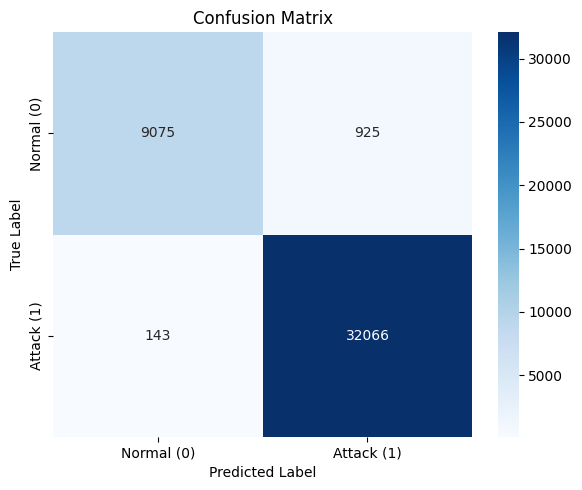

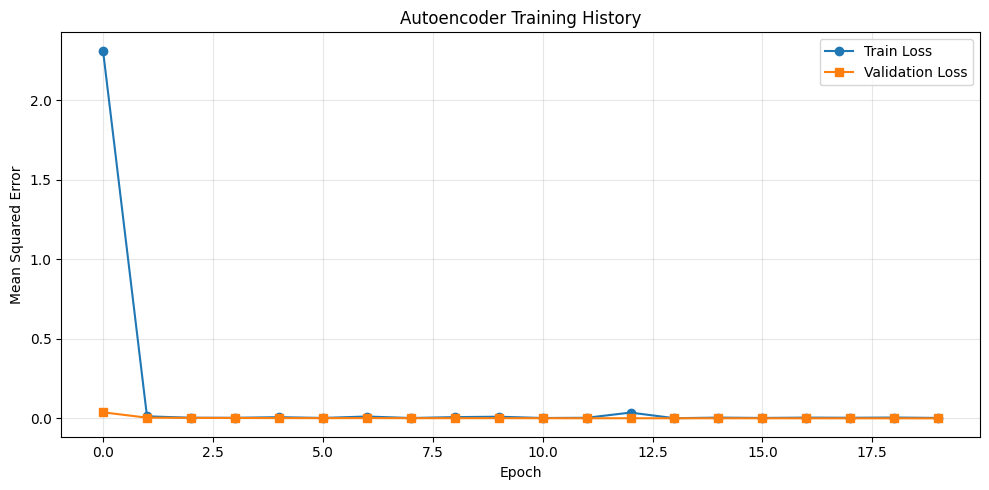

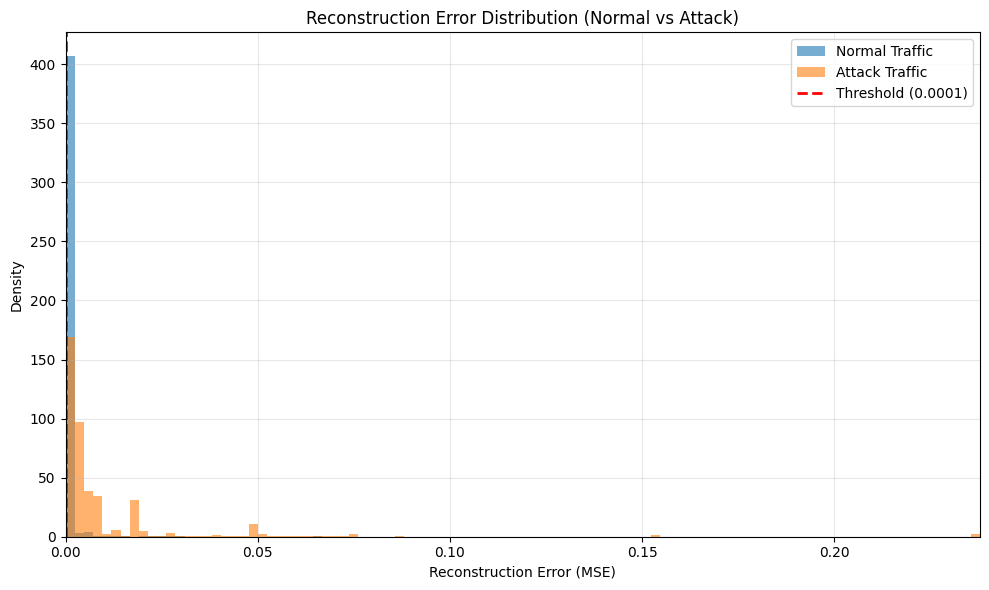


 All plots generated successfully.


In [ ]:

# TRUE HYBRID (Domain + Filter + Performance Pruning ONLY) + ANALYSIS & PLOTS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
import warnings
warnings.filterwarnings('ignore')
import random
random.seed(42)
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

print("REAL HYBRID: DOMAIN & FILTER & PRUNING")



# 1. LOAD DATA
df = pd.read_csv('train_test_network.csv')
df = df.replace('-', np.nan)

# Fill missing
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(0)

for col in df.select_dtypes(include='object').columns:
    if col not in ['label', 'type']:
        df[col] = df[col].fillna('unknown')

# Feature engineering
def port_category(p):
    if p <= 1023: return 0
    elif p <= 49151: return 1
    else: return 2

df['dst_port'] = df['dst_port'].apply(port_category)

# Prepare
X = df.drop(columns=['label', 'type'], errors='ignore')
y = df['label']

# Encode
for col in X.select_dtypes(include='object').columns:
    X[col] = LabelEncoder().fit_transform(X[col])

print(f"\n Total Features: {X.shape[1]}")


# 2. PREPROCESSING
for col in X.columns:
    X[col] = X[col].clip(X[col].quantile(0.01), X[col].quantile(0.99))

scaler = RobustScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


# 3. DOMAIN FEATURES (START POINT)

manual_features = [
    'dst_port','proto','duration','src_bytes','dst_bytes',
    'conn_state','missed_bytes','src_pkts',
    'src_ip_bytes','dst_pkts','dst_ip_bytes'
]

print(f"\n Manual Features: {len(manual_features)}")


# 4. FILTER VALIDATION (ONLY REMOVE, NOT ADD)

selector = VarianceThreshold(0.01)
selector.fit(X_train)

valid_features = X_train.columns[selector.get_support()]

# Keep only manual features that pass variance filter
filtered_manual = [f for f in manual_features if f in valid_features]

# Correlation removal
corr = X_train[filtered_manual].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [c for c in upper.columns if any(upper[c] > 0.95)]

hybrid_features = [f for f in filtered_manual if f not in to_drop]

print(f"\n After filter validation: {len(hybrid_features)} features")


# 5. AUTOENCODER FUNCTION (For Pruning)

def evaluate(features):
    X_tr = X_train[features]
    X_te = X_test[features]

    X_norm = X_tr[y_train == 0]
    X_val = X_norm.sample(frac=0.2, random_state=42)
    X_tr_final = X_norm.drop(X_val.index)

    inp = Input(shape=(X_tr_final.shape[1],))
    x = Dense(32, activation='relu')(inp)
    x = Dense(16, activation='relu')(x)
    x = Dense(32, activation='relu')(x)
    out = Dense(X_tr_final.shape[1], activation='linear')(x)

    model = Model(inp, out)
    model.compile(optimizer='adam', loss='mse')

    model.fit(X_tr_final, X_tr_final,
              epochs=20, batch_size=64,
              validation_data=(X_val, X_val),
              verbose=0)

    # Threshold
    val_pred = model.predict(X_val, verbose=0)
    val_mse = np.mean((X_val - val_pred)**2, axis=1)
    threshold = np.percentile(val_mse, 85)

    # Test
    test_pred = model.predict(X_te, verbose=0)
    test_mse = np.mean((X_te - test_pred)**2, axis=1)
    y_pred = (test_mse > threshold).astype(int)

    return f1_score(y_test, y_pred), precision_score(y_test, y_pred), recall_score(y_test, y_pred)


# 6. PERFORMANCE-BASED PRUNING (KEY HYBRID STEP)

current_features = hybrid_features.copy()
best_f1, _, _ = evaluate(current_features)

improved = True
while improved:
    improved = False
    for f in current_features.copy():
        temp_features = [x for x in current_features if x != f]
        if len(temp_features) < 5: continue

        f1, _, _ = evaluate(temp_features)
        if f1 > best_f1:
            print(f" Removed '{f}' → F1 improved {best_f1:.4f} → {f1:.4f}")
            current_features = temp_features
            best_f1 = f1
            improved = True
            break

final_features = current_features
print("\n FINAL HYBRID FEATURES:")
print(final_features)
print(f"Total: {len(final_features)}")

# 7. FINAL TRAINING & COMPREHENSIVE ANALYSIS
def train_and_analyze(features, name):
    print(f"\n Training final model for: {name}")

    X_tr = X_train[features]
    X_te = X_test[features]

    X_norm = X_tr[y_train == 0]
    X_val = X_norm.sample(frac=0.2, random_state=42)
    X_tr_final = X_norm.drop(X_val.index)

    # Build Model
    inp = Input(shape=(X_tr_final.shape[1],))
    x = Dense(32, activation='relu')(inp)
    x = Dense(16, activation='relu')(x)
    x = Dense(32, activation='relu')(x)
    out = Dense(X_tr_final.shape[1], activation='linear')(x)

    model = Model(inp, out)
    model.compile(optimizer='adam', loss='mse')

    # Train
    history = model.fit(X_tr_final, X_tr_final,
                        epochs=20, batch_size=64,
                        validation_data=(X_val, X_val),
                        verbose=0)

    # Threshold & Predict
    val_pred = model.predict(X_val, verbose=0)
    val_mse = np.mean((X_val - val_pred)**2, axis=1)
    threshold = np.percentile(val_mse, 85)

    test_pred = model.predict(X_te, verbose=0)
    test_mse = np.mean((X_te - test_pred)**2, axis=1)
    y_pred = (test_mse > threshold).astype(int)

    # Metrics
    f1 = f1_score(y_test, y_pred)
    p = precision_score(y_test, y_pred)
    r = recall_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f" {name} Complete | F1: {f1:.4f} | Precision: {p:.4f} | Recall: {r:.4f}")
    return model, history, threshold, test_mse, y_pred, cm, {'F1': f1, 'Precision': p, 'Recall': r}

# Run final analysis on the best pruned features
model, history, threshold, test_mse, y_pred, cm, metrics = train_and_analyze(final_features, "Hybrid (Pruned)")

# 8. VISUALIZATIONS & PRINTED SUMMARY


print("FINAL METRICS SUMMARY")

print(f"Features Used: {len(final_features)}")
print(f"Features: {final_features}")
print(f"Threshold (85th percentile): {threshold:.6f}")
print(f"Precision: {metrics['Precision']:.4f}")
print(f"Recall:    {metrics['Recall']:.4f}")
print(f"F1-Score:  {metrics['F1']:.4f}")


# Plot 1: Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Attack (1)'],
            yticklabels=['Normal (0)', 'Attack (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Plot 2: Training History
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='s')
plt.title('Autoencoder Training History')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 3: Reconstruction Error Distribution
plt.figure(figsize=(10, 6))
test_mse_normal = test_mse[y_test == 0]
test_mse_attack = test_mse[y_test == 1]

plt.hist(test_mse_normal, bins=100, alpha=0.6, label='Normal Traffic', density=True, range=(0, np.percentile(test_mse, 99)))
plt.hist(test_mse_attack, bins=100, alpha=0.6, label='Attack Traffic', density=True, range=(0, np.percentile(test_mse, 99)))
plt.axvline(x=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold ({threshold:.4f})')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Density')
plt.title('Reconstruction Error Distribution (Normal vs Attack)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, np.percentile(test_mse, 99))w
plt.tight_layout()
plt.show()

print("\n All plots generated successfully.")

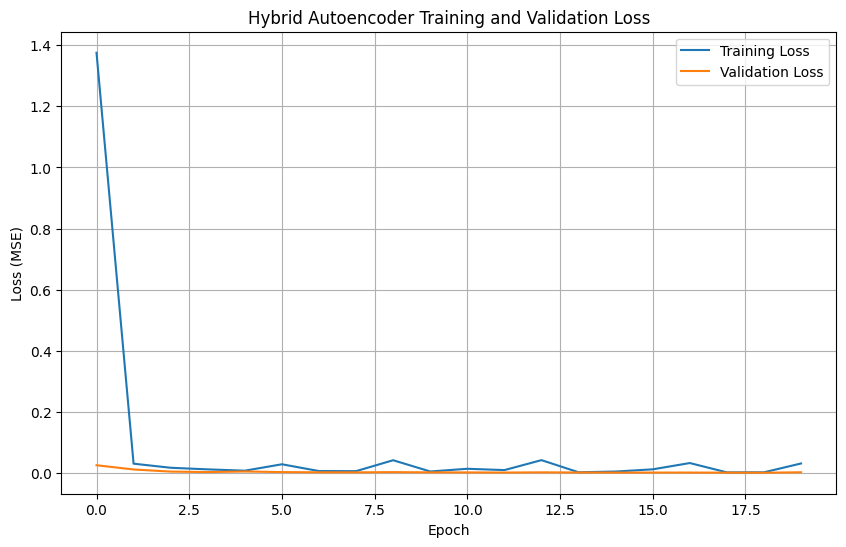

In [ ]:
import matplotlib.pyplot as plt

if 'history' in globals():
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Hybrid Autoencoder Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("The 'history' object from the hybrid model training was not found. Please ensure the relevant cell has been run.")

# Quantization

In [ ]:
# Save trained hybrid model
model.save("hybrid_autoencoder.h5")

print(" Hybrid model saved.")

 Hybrid model saved.


In [ ]:
import tensorflow as tf
import os

# Load saved model without compiling, as compilation state is not needed for TFLite conversion
loaded_model = tf.keras.models.load_model("hybrid_autoencoder.h5", compile=False)

# Create TensorFlow Lite converter
converter = tf.lite.TFLiteConverter.from_keras_model(loaded_model)

# Enable dynamic range quantization
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Convert model
tflite_model = converter.convert()

# Save quantized model
with open("hybrid_autoencoder_quantized.tflite", "wb") as f:
    f.write(tflite_model)

print(" Quantized TensorFlow Lite model created.")

Saved artifact at '/tmp/tmp0__ff8ey'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 6), dtype=tf.float32, name='input_layer_37')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  135170933605392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135170913318096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135170913313680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135170913310416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135170913313488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135170913307536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135170913312336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135170913311568: TensorSpec(shape=(), dtype=tf.resource, name=None)
 Quantized TensorFlow Lite model created.


In [ ]:
# Compare file sizes

original_size = os.path.getsize("hybrid_autoencoder.h5") / 1024
quantized_size = os.path.getsize("hybrid_autoencoder_quantized.tflite") / 1024

print(f"Original Model Size: {original_size:.2f} KB")
print(f"Quantized Model Size: {quantized_size:.2f} KB")

reduction = ((original_size - quantized_size) / original_size) * 100

print(f"Model Size Reduction: {reduction:.2f}%")

Original Model Size: 49.92 KB
Quantized Model Size: 8.11 KB
Model Size Reduction: 83.76%


In [ ]:
import joblib

joblib.dump(scaler, "scaler.pkl")

print("Scaler saved.")

Scaler saved.


In [ ]:
import json

with open("final_features.json", "w") as f:
    json.dump(final_features, f)

print("Features saved.")

Features saved.


# ZERO-DAY ATTACK DETECTION

 ZERO-DAY ATTACK DETECTION EXPERIMENT

 Available attack types in test set:
type
dos           4117
backdoor      4053
scanning      4041
ddos          4004
xss           4002
password      3980
ransomware    3903
injection     3900
mitm           209

     Selected zero-day attack type: 'dos'
     (4117 samples in test set)

 Building zero-day train/test splits

     Training samples (clean normal): 32,000
     Validation samples:              8,000
     Test — Normal:                  10,000
     Test — Known attacks:           28,092
     Test — Zero-day (dos): 4,117
\ Training hybrid feature zero-day model 
     Threshold (85th pct validation MSE): 0.000227

 Evaluating detection on each traffic category
 ZERO-DAY DETECTION RESULTS

 Traffic Category          Samples    Detection Rate
 
 Normal traffic             10,000       8.3%  (false positives)
 Known attacks              28,092      98.2%  (seen attack types)
 Zero-day (dos         )    4,117      93.4%  (unseen attack type)

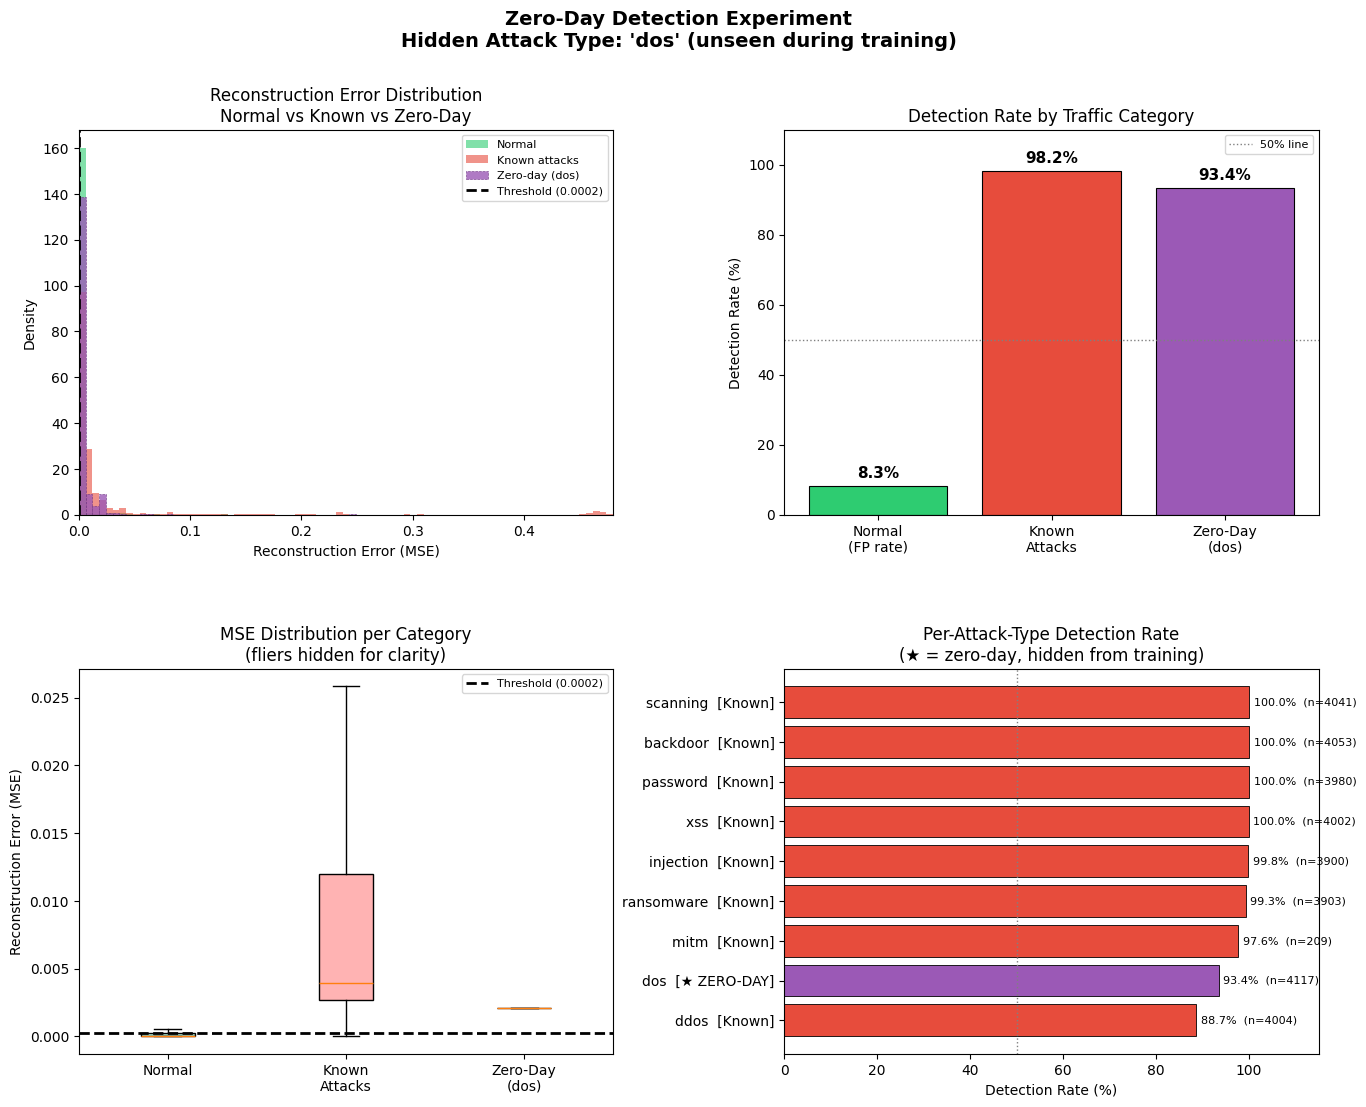

     Figure saved: zero_day_experiment.png
 SUMMARY TABLE — Zero-Day Experiment


,Value
Metric,
Zero-day attack type hidden,dos
Zero-day samples in test set,4117
Zero-day detection rate,93.4%
Known attack detection rate,98.2%
False positive rate (normal traffic),8.3%
Overall F1 Score,0.9753
Overall Precision,0.9743
Overall Recall,0.9762
Detection threshold,0.000227


 LEAVE-ONE-OUT ZERO-DAY SUMMARY
  backdoor             → 100.0% detected (n=4053)
  ddos                 → 98.9% detected (n=4004)
  dos                  → 93.4% detected (n=4117)
  injection            → 99.8% detected (n=3900)
  mitm                 → 96.7% detected (n=209)
  password             → 100.0% detected (n=3980)
  ransomware           → 89.0% detected (n=3903)
  scanning             → 83.1% detected (n=4041)
  xss                  → 100.0% detected (n=4002)


,Samples,Detection Rate,Avg MSE (zero-day),Threshold
Hidden Attack Type,,,,
backdoor,4053,100.0%,0.0046,0.0003
ddos,4004,98.9%,0.0170,0.0005
dos,4117,93.4%,0.0055,0.0005
injection,3900,99.8%,0.0822,0.0007
mitm,209,96.7%,0.0350,0.0003
password,3980,100.0%,0.0070,0.0003
ransomware,3903,89.0%,0.0039,0.0008
scanning,4041,83.1%,0.0049,0.0028
xss,4002,100.0%,0.0497,0.0006


In [ ]:
# ZERO-DAY ATTACK DETECTION EXPERIMENT

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             confusion_matrix, classification_report)
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

warnings.filterwarnings('ignore')


print(" ZERO-DAY ATTACK DETECTION EXPERIMENT")

required_vars = ['final_features', 'X_train', 'X_test', 'y_train', 'y_test']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise ValueError(
        f"Missing variables: {missing}\n"
        "Please run the Hybrid Autoencoder cell before this one."
    )

#  Step 1: Load Attack Type Labels

df_raw = pd.read_csv('train_test_network.csv')
df_raw = df_raw.replace('-', np.nan)

num_cols_raw = df_raw.select_dtypes(include=[np.number]).columns
df_raw[num_cols_raw] = df_raw[num_cols_raw].fillna(0)

for col in df_raw.select_dtypes(include='object').columns:
    if col not in ['label', 'type']:
        df_raw[col] = df_raw[col].fillna('unknown')

def port_category(p):
    if p <= 1023:   return 0
    elif p <= 49151: return 1
    else:            return 2

df_raw['dst_port'] = df_raw['dst_port'].apply(port_category)

X_raw  = df_raw.drop(columns=['label', 'type'], errors='ignore')
y_raw  = df_raw['label']
t_raw  = df_raw['type']

for col in X_raw.select_dtypes(include='object').columns:
    X_raw[col] = LabelEncoder().fit_transform(X_raw[col])

for col in X_raw.columns:
    X_raw[col] = X_raw[col].clip(
        X_raw[col].quantile(0.01),
        X_raw[col].quantile(0.99)
    )

scaler_zd = RobustScaler()
X_raw_scaled = pd.DataFrame(
    scaler_zd.fit_transform(X_raw), columns=X_raw.columns
)

# Re-spliting with same seed to align type labels with X_test / y_test
_, _, _, _, t_train_full, t_test_full = train_test_split(
    X_raw_scaled, y_raw, t_raw,
    test_size=0.2, stratify=y_raw, random_state=42
)
t_test_full = t_test_full.reset_index(drop=True)

# Work on final hybrid features only
X_train_zd = X_train[final_features].reset_index(drop=True)
X_test_zd  = X_test[final_features].reset_index(drop=True)
y_train_zd = y_train.reset_index(drop=True)
y_test_zd  = y_test.reset_index(drop=True)

# Step 2: Choose the Zero-Day Attack Type


attack_counts = t_test_full[y_test_zd == 1].value_counts()
print("\n Available attack types in test set:")
print(attack_counts.to_string())

#  CONFIGURATION: Change this to any attack type in the list above
ZERO_DAY_ATTACK = attack_counts.index[0]   # defaults to the most common type
# To manually set: ZERO_DAY_ATTACK = 'ransomware'
#

print(f"\n     Selected zero-day attack type: '{ZERO_DAY_ATTACK}'")
print(f"     ({attack_counts[ZERO_DAY_ATTACK]} samples in test set)")

#  Step 3: Build Zero-Day Train/Test Split
# Training set: normal traffic only, with zero-day type COMPLETELY removed
# Test set A:   known attacks  (seen attack types)
# Test set B:   zero-day only  (the hidden attack type)

print("\n Building zero-day train/test splits")

# Training mask: normal traffic, excluding any zero-day samples
train_mask_normal     = (y_train_zd == 0)
train_mask_known_atk  = (y_train_zd == 1)

# Completely remove zero-day type from training pool
zeroday_in_train = t_train_full.reset_index(drop=True) == ZERO_DAY_ATTACK
train_mask_clean = train_mask_normal & ~zeroday_in_train

X_train_zd_clean  = X_train_zd[train_mask_clean]
# Validation split from clean normal traffic
X_val_zd   = X_train_zd_clean.sample(frac=0.2, random_state=42)
X_tr_final = X_train_zd_clean.drop(X_val_zd.index)

# Test set masks
mask_normal   = (y_test_zd == 0)
mask_zeroday  = (t_test_full == ZERO_DAY_ATTACK) & (y_test_zd == 1)
mask_known    = (y_test_zd == 1) & (t_test_full != ZERO_DAY_ATTACK)

X_test_normal  = X_test_zd[mask_normal]
X_test_zeroday = X_test_zd[mask_zeroday]
X_test_known   = X_test_zd[mask_known]

print(f"\n     Training samples (clean normal): {len(X_tr_final):,}")
print(f"     Validation samples:              {len(X_val_zd):,}")
print(f"     Test — Normal:                  {len(X_test_normal):,}")
print(f"     Test — Known attacks:           {len(X_test_known):,}")
print(f"     Test — Zero-day ({ZERO_DAY_ATTACK}): {len(X_test_zeroday):,}")

if len(X_test_zeroday) == 0:
    raise ValueError(
        f"No '{ZERO_DAY_ATTACK}' samples found in test set. "
        "Try a different ZERO_DAY_ATTACK value."
    )

#  Step 4: Train Zero-Day Model


print("\ Training hybrid feature zero-day model ")

input_dim_zd = X_tr_final.shape[1]

inp_zd  = Input(shape=(input_dim_zd,))
x_zd    = Dense(32, activation='relu')(inp_zd)
x_zd    = Dense(24, activation='relu')(x_zd)
x_zd    = Dense(16, activation='relu')(x_zd)
x_zd    = Dense(24, activation='relu')(x_zd)
x_zd    = Dense(32, activation='relu')(x_zd)
out_zd  = Dense(input_dim_zd, activation='linear')(x_zd)

zeroday_model = Model(inp_zd, out_zd)
zeroday_model.compile(optimizer='adam', loss='mse')

history_zd = zeroday_model.fit(
    X_tr_final, X_tr_final,
    epochs=20, batch_size=64,
    validation_data=(X_val_zd, X_val_zd),
    shuffle=True, verbose=0
)

# Threshold from validation reconstruction error (same 85th percentile rule)
val_pred_zd  = zeroday_model.predict(X_val_zd, verbose=0)
val_mse_zd   = np.mean((X_val_zd.values - val_pred_zd) ** 2, axis=1)
threshold_zd = np.percentile(val_mse_zd, 85)

print(f"     Threshold (85th pct validation MSE): {threshold_zd:.6f}")

#  Step 5: Evaluate Zero-Day Detection

print("\n Evaluating detection on each traffic category")

def get_mse_and_preds(model, X, threshold):
    """Returns reconstruction errors and binary predictions."""
    X_arr  = X.values if hasattr(X, 'values') else X
    recon  = model.predict(X_arr, verbose=0)
    mse    = np.mean((X_arr - recon) ** 2, axis=1)
    preds  = (mse > threshold).astype(int)
    return mse, preds

mse_normal,   pred_normal   = get_mse_and_preds(zeroday_model, X_test_normal,  threshold_zd)
mse_known,    pred_known    = get_mse_and_preds(zeroday_model, X_test_known,   threshold_zd)
mse_zeroday,  pred_zeroday  = get_mse_and_preds(zeroday_model, X_test_zeroday, threshold_zd)

# Detection rates
normal_flagged_rate  = pred_normal.mean()
known_detected_rate  = pred_known.mean()
zeroday_detected_rate = pred_zeroday.mean()

# Full test combining all categories for overall metrics
X_combined = pd.concat([X_test_normal, X_test_known, X_test_zeroday])
y_combined = np.concatenate([
    np.zeros(len(X_test_normal)),
    np.ones(len(X_test_known)),
    np.ones(len(X_test_zeroday))
])

_, pred_combined = get_mse_and_preds(zeroday_model, X_combined, threshold_zd)

overall_f1        = f1_score(y_combined, pred_combined)
overall_precision = precision_score(y_combined, pred_combined)
overall_recall    = recall_score(y_combined, pred_combined)

# Per-attack-type detection in test set
print(" ZERO-DAY DETECTION RESULTS")


print(f"""
 Traffic Category          Samples    Detection Rate

 Normal traffic            {len(X_test_normal):>7,}    {normal_flagged_rate*100:>6.1f}%  (false positives)
 Known attacks             {len(X_test_known):>7,}    {known_detected_rate*100:>6.1f}%  (seen attack types)
 Zero-day ({ZERO_DAY_ATTACK:<12})  {len(X_test_zeroday):>7,}    {zeroday_detected_rate*100:>6.1f}%  (unseen attack type)

 Overall (combined test set):
   F1 Score:   {overall_f1:.4f}
   Precision:  {overall_precision:.4f}
   Recall:     {overall_recall:.4f}
""")

#  Interpretation guidance
print(" INTERPRETATION:")
if zeroday_detected_rate >= 0.80:
    print(f"  STRONG zero-day detection: {zeroday_detected_rate*100:.1f}% of unseen")
    print(f"    '{ZERO_DAY_ATTACK}' attacks flagged as anomalous.")
    print("    The model generalises beyond known attack signatures.")
elif zeroday_detected_rate >= 0.50:
    print(f"   MODERATE zero-day detection: {zeroday_detected_rate*100:.1f}% of unseen")
    print(f"    '{ZERO_DAY_ATTACK}' attacks flagged.")
    print("    Partial detection — traffic profile partially overlaps normal.")
else:
    print(f"  LOW zero-day detection: {zeroday_detected_rate*100:.1f}% of unseen")
    print(f"    '{ZERO_DAY_ATTACK}' attacks flagged.")
    print("    This attack type closely resembles normal traffic — a known")


#  Step 6: Visualisation


fig = plt.figure(figsize=(16, 12))
fig.suptitle(
    f"Zero-Day Detection Experiment\n"
    f"Hidden Attack Type: '{ZERO_DAY_ATTACK}' (unseen during training)",
    fontsize=14, fontweight='bold', y=0.98
)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.32)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

#  Plot 1: Reconstruction Error Distributions
max_x = np.percentile(
    np.concatenate([mse_normal, mse_known, mse_zeroday]), 99
)
bins = np.linspace(0, max_x, 80)

ax1.hist(mse_normal,  bins=bins, alpha=0.6, label='Normal',
         color='#2ecc71', density=True)
ax1.hist(mse_known,   bins=bins, alpha=0.6, label='Known attacks',
         color='#e74c3c', density=True)
ax1.hist(mse_zeroday, bins=bins, alpha=0.8, label=f'Zero-day ({ZERO_DAY_ATTACK})',
         color='#9b59b6', density=True, linestyle='--',
         edgecolor='#6c3483', linewidth=0.5)
ax1.axvline(x=threshold_zd, color='black', linestyle='--',
            linewidth=2, label=f'Threshold ({threshold_zd:.4f})')
ax1.set_xlabel('Reconstruction Error (MSE)')
ax1.set_ylabel('Density')
ax1.set_title('Reconstruction Error Distribution\nNormal vs Known vs Zero-Day')
ax1.legend(fontsize=8)
ax1.set_xlim(0, max_x)

#  Plot 2: Detection Rate Bar Chart
categories  = ['Normal\n(FP rate)', 'Known\nAttacks', f'Zero-Day\n({ZERO_DAY_ATTACK})']
rates       = [normal_flagged_rate, known_detected_rate, zeroday_detected_rate]
bar_colors  = ['#2ecc71', '#e74c3c', '#9b59b6']

bars = ax2.bar(categories, [r * 100 for r in rates],
               color=bar_colors, edgecolor='black', linewidth=0.8)
ax2.axhline(y=50, color='gray', linestyle=':', linewidth=1, label='50% line')
ax2.set_ylabel('Detection Rate (%)')
ax2.set_title('Detection Rate by Traffic Category')
ax2.set_ylim(0, 110)
ax2.legend(fontsize=8)

for bar, rate in zip(bars, rates):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f'{rate*100:.1f}%',
        ha='center', va='bottom', fontweight='bold', fontsize=11
    )

#  Plot 3: MSE Box Plot per Category
box_data   = [mse_normal, mse_known, mse_zeroday]
box_labels = ['Normal', 'Known\nAttacks', f'Zero-Day\n({ZERO_DAY_ATTACK})']

bp = ax3.boxplot(box_data, labels=box_labels, patch_artist=True,
                 showfliers=False, notch=False)

box_fill_colors = ['#a8e6cf', '#ffb3b3', '#d2b4de']
for patch, color in zip(bp['boxes'], box_fill_colors):
    patch.set_facecolor(color)

ax3.axhline(y=threshold_zd, color='black', linestyle='--',
            linewidth=2, label=f'Threshold ({threshold_zd:.4f})')
ax3.set_ylabel('Reconstruction Error (MSE)')
ax3.set_title('MSE Distribution per Category\n(fliers hidden for clarity)')
ax3.legend(fontsize=8)

#  Plot 4: Per-Attack-Type Detection Heatmap
all_attack_types = t_test_full[y_test_zd == 1].unique()
detection_rows   = []

for atk in sorted(all_attack_types):
    mask_atk = (t_test_full == atk) & (y_test_zd == 1)
    X_atk    = X_test_zd[mask_atk.values]
    if len(X_atk) == 0:
        continue
    mse_atk, pred_atk = get_mse_and_preds(zeroday_model, X_atk, threshold_zd)
    is_zeroday = '★ ZERO-DAY' if atk == ZERO_DAY_ATTACK else 'Known'
    detection_rows.append({
        'Attack Type': f"{atk}  [{is_zeroday}]",
        'Samples': len(X_atk),
        'Detection Rate': pred_atk.mean()
    })

det_df = pd.DataFrame(detection_rows).sort_values('Detection Rate', ascending=True)

colors_bar = [
    '#9b59b6' if '★' in row['Attack Type'] else '#e74c3c'
    for _, row in det_df.iterrows()
]

bars4 = ax4.barh(
    det_df['Attack Type'],
    det_df['Detection Rate'] * 100,
    color=colors_bar, edgecolor='black', linewidth=0.6
)
ax4.axvline(x=50, color='gray', linestyle=':', linewidth=1)
ax4.set_xlabel('Detection Rate (%)')
ax4.set_title('Per-Attack-Type Detection Rate\n(★ = zero-day, hidden from training)')
ax4.set_xlim(0, 115)

for bar, (_, row) in zip(bars4, det_df.iterrows()):
    ax4.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{row['Detection Rate']*100:.1f}%  (n={row['Samples']})",
        va='center', fontsize=8
    )

plt.savefig('zero_day_experiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("     Figure saved: zero_day_experiment.png")

#  Summary Table
print(" SUMMARY TABLE — Zero-Day Experiment")

summary_df = pd.DataFrame([
    {
        'Metric': 'Zero-day attack type hidden',
        'Value': ZERO_DAY_ATTACK
    },
    {
        'Metric': 'Zero-day samples in test set',
        'Value': len(X_test_zeroday)
    },
    {
        'Metric': 'Zero-day detection rate',
        'Value': f"{zeroday_detected_rate*100:.1f}%"
    },
    {
        'Metric': 'Known attack detection rate',
        'Value': f"{known_detected_rate*100:.1f}%"
    },
    {
        'Metric': 'False positive rate (normal traffic)',
        'Value': f"{normal_flagged_rate*100:.1f}%"
    },
    {
        'Metric': 'Overall F1 Score',
        'Value': f"{overall_f1:.4f}"
    },
    {
        'Metric': 'Overall Precision',
        'Value': f"{overall_precision:.4f}"
    },
    {
        'Metric': 'Overall Recall',
        'Value': f"{overall_recall:.4f}"
    },
    {
        'Metric': 'Detection threshold',
        'Value': f"{threshold_zd:.6f}"
    },
    {
        'Metric': 'Features used',
        'Value': str(final_features)
    },
])

display(summary_df.set_index('Metric'))

#  Repeat for all attack types (leave-one-out summary)
print(" LEAVE-ONE-OUT ZERO-DAY SUMMARY")

loo_results = []
all_types   = t_test_full[y_test_zd == 1].unique()

for hidden_type in sorted(all_types):

    mask_zd  = (t_test_full == hidden_type) & (y_test_zd == 1)
    X_hidden = X_test_zd[mask_zd.values]

    if len(X_hidden) < 10:
        continue   # skip tiny groups

    # Quick model — fewer epochs for speed
    X_norm_loo  = X_train_zd[y_train_zd == 0]
    X_val_loo   = X_norm_loo.sample(frac=0.2, random_state=42)
    X_tr_loo    = X_norm_loo.drop(X_val_loo.index)

    inp_loo = Input(shape=(input_dim_zd,))
    x_loo   = Dense(32, activation='relu')(inp_loo)
    x_loo   = Dense(16, activation='relu')(x_loo)
    x_loo   = Dense(32, activation='relu')(x_loo)
    out_loo = Dense(input_dim_zd, activation='linear')(x_loo)
    m_loo   = Model(inp_loo, out_loo)
    m_loo.compile(optimizer='adam', loss='mse')

    m_loo.fit(X_tr_loo, X_tr_loo,
              epochs=15, batch_size=64,
              validation_data=(X_val_loo, X_val_loo),
              verbose=0)

    vp      = m_loo.predict(X_val_loo, verbose=0)
    vm      = np.mean((X_val_loo.values - vp) ** 2, axis=1)
    thr_loo = np.percentile(vm, 85)

    mse_h, pred_h = get_mse_and_preds(m_loo, X_hidden, thr_loo)

    loo_results.append({
        'Hidden Attack Type': hidden_type,
        'Samples': len(X_hidden),
        'Detection Rate': f"{pred_h.mean()*100:.1f}%",
        'Avg MSE (zero-day)': f"{mse_h.mean():.4f}",
        'Threshold': f"{thr_loo:.4f}"
    })
    print(f"  {hidden_type:<20} → {pred_h.mean()*100:.1f}% detected "
          f"(n={len(X_hidden)})")

loo_df = pd.DataFrame(loo_results).set_index('Hidden Attack Type')
display(loo_df)



# SHAP EXPLAINABILITY

In [ ]:
pip install shap

SHAP EXPLAINABILITY 
 All required variables found (X_train, X_test, y_train, final_features)
 SHAP background data prepared using 6 final features: (32000, 6)
 SHAP explainer created


ExactExplainer explainer: 51it [00:26,  1.52it/s]


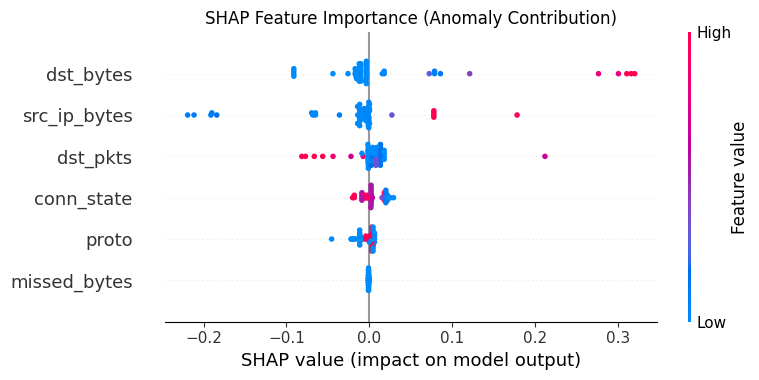

 SHAP summary plot saved


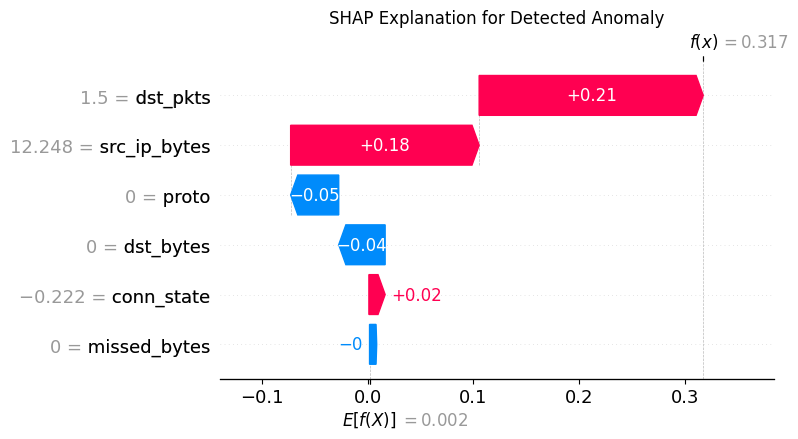

 SHAP waterfall plot saved

 TOP FEATURE CONTRIBUTIONS FOR ANOMALY:
dst_pkts: 0.2121
src_ip_bytes: 0.1784
proto: -0.0455
dst_bytes: -0.0439
conn_state: 0.0154


In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense


print("SHAP EXPLAINABILITY ")



# 1. CHECK REQUIRED VARIABLES

required_vars = ['X_train', 'X_test', 'y_train', 'final_features']

for var in required_vars:
    if var not in globals():
        raise ValueError(f" Missing required variable: {var}")

print(" All required variables found (X_train, X_test, y_train, final_features)")

# 2. PREPARE DATA AND RE-BUILD/TRAIN AUTOENCODER

# Use final_features
X_train_selected = X_train[final_features]
X_test_selected = X_test[final_features]

# Normal-only training data
X_train_normal = X_train_selected[y_train == 0]
X_val_normal = X_train_normal.sample(frac=0.2, random_state=42)
X_train_final = X_train_normal.drop(X_val_normal.index)

print(f" SHAP background data prepared using {len(final_features)} final features: {X_train_final.shape}")

# Re-build and train the autoencoder model
input_dim = X_train_final.shape[1]
input_layer = Input(shape=(input_dim,))
encoded = Dense(32, activation="relu")(input_layer)
encoded = Dense(24, activation="relu")(encoded)
encoded = Dense(16, activation="relu")(encoded)
decoded = Dense(24, activation="relu")(encoded)
decoded = Dense(32, activation="relu")(decoded)
decoded = Dense(input_dim, activation="linear")(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mse')


# Use same training parameters as in the Hybrid cell's autoencoder function
history = autoencoder.fit(
    X_train_final, X_train_final,
    epochs=20,
    batch_size=64,
    validation_data=(X_val_normal, X_val_normal),
    shuffle=True, verbose=0
)


# 3. DEFINE ANOMALY SCORE FUNCTION

def anomaly_score(X_input):
    preds = autoencoder.predict(X_input, verbose=0)
    return np.mean((X_input - preds)**2, axis=1)


# 4. CREATE SHAP EXPLAINER
background = X_train_final.sample(min(100, len(X_train_final)), random_state=42)

explainer = shap.Explainer(anomaly_score, background)

print(" SHAP explainer created")

# 5. SELECT TEST SAMPLES

X_sample = X_test_selected.sample(min(50, len(X_test_selected)), random_state=42)

shap_values = explainer(X_sample)


# 6. GLOBAL EXPLANATION (Feature Importance)

plt.figure()
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("SHAP Feature Importance (Anomaly Contribution)")
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=300)
plt.show()

print(" SHAP summary plot saved")


# 7. LOCAL EXPLANATION (Single Anomaly)

# Find most anomalous sample
scores = anomaly_score(X_sample.values)
idx = np.argmax(scores)

plt.figure()
shap.plots.waterfall(shap_values[idx], show=False)
plt.title("SHAP Explanation for Detected Anomaly")
plt.tight_layout()
plt.savefig("shap_waterfall.png", dpi=300)
plt.show()

print(" SHAP waterfall plot saved")


# 8. EXPLANATION

feature_contributions = dict(zip(X_sample.columns, shap_values[idx].values))

sorted_features = sorted(feature_contributions.items(), key=lambda x: abs(x[1]), reverse=True)

print("\n TOP FEATURE CONTRIBUTIONS FOR ANOMALY:")
for f, val in sorted_features[:5]:
    print(f"{f}: {val:.4f}")

# BASELINE MODELS

In [ ]:
# STORE AUTOENCODER RESULTS
results = []

# Extract metrics directly from the previous cell's output
if 'metrics' not in globals() or 'y_test' not in globals() or 'y_pred' not in globals():
    raise ValueError("Required variables (metrics, y_test, y_pred) not found. Please run the 'TRUE HYBRID' analysis cell first.")

# Calculate accuracy since it wasn't explicitly stored in the metrics dictionary
from sklearn.metrics import accuracy_score
hybrid_acc = accuracy_score(y_test, y_pred)

results.append({
    'Model': 'Autoencoder (Hybrid)',
    'Precision': metrics['Precision'],
    'Recall': metrics['Recall'],
    'F1-Score': metrics['F1'],
    'Accuracy': hybrid_acc
})
print(f"Autoencoder (Hybrid) stored: F1={metrics['F1']:.4f}")

Autoencoder (Hybrid) stored: F1=0.9836


# ISOLATION FOREST MODEL

In [ ]:

# MODEL 2: ISOLATION FOREST

import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

print(" ISOLATION FOREST")

# Ensure final_features, X, y are available from previous cells
if 'final_features' not in globals() or \
   'X' not in globals() or \
   'y' not in globals():
    raise ValueError("Required variables (final_features, X, y) not found. Please run previous data loading and feature selection cells.")

# Use only final_features for this model
X_filtered = X[final_features]
y_filtered = y

# Split data using the filtered features
X_train_filtered, X_test_filtered, y_train_filtered, y_test_filtered = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered
)

# Prepare training data (normal samples only for unsupervised models)
X_train_anom_filtered = X_train_filtered[y_train_filtered == 0]

iso_model = IsolationForest(n_estimators=100, contamination=0.05, random_state=42, n_jobs=-1)
iso_model.fit(X_train_anom_filtered)
iso_pred = (iso_model.predict(X_test_filtered) == -1).astype(int)

print(classification_report(y_test_filtered, iso_pred, target_names=['Normal', 'Attack']))

iso_p = precision_score(y_test_filtered, iso_pred, pos_label=1)
iso_r = recall_score(y_test_filtered, iso_pred, pos_label=1)
iso_f1 = f1_score(y_test_filtered, iso_pred, pos_label=1)
iso_acc = accuracy_score(y_test_filtered, iso_pred)

results.append({
    'Model': 'Isolation Forest (Hybrid Features)',
    'Precision': iso_p,
    'Recall': iso_r,
    'F1-Score': iso_f1,
    'Accuracy': iso_acc
})
print(f" Isolation Forest (Hybrid Features) F1: {iso_f1:.4f}")


 ISOLATION FOREST
              precision    recall  f1-score   support

      Normal       0.30      0.95      0.46     10000
      Attack       0.96      0.32      0.48     32209

    accuracy                           0.47     42209
   macro avg       0.63      0.64      0.47     42209
weighted avg       0.80      0.47      0.47     42209

 Isolation Forest (Hybrid Features) F1: 0.4772


# ONE-CLASS SVM MODEL

In [ ]:


print(" ONE-CLASS SVM")

import pandas as pd
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# Ensure final_features, X, y are available from previous cells
if 'final_features' not in globals() or \
   'X' not in globals() or \
   'y' not in globals():
    raise ValueError("Required variables (final_features, X, y) not found. Please run previous data loading and feature selection cells.")

# Use only final_features for this model
X_filtered = X[final_features]
y_filtered = y

# Split data using the filtered features
X_train_filtered, X_test_filtered, y_train_filtered, y_test_filtered = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered
)

# Prepare training data (normal samples only for unsupervised models)
X_train_anom_filtered = X_train_filtered[y_train_filtered == 0]

ocsvm_model = OneClassSVM(kernel='rbf', gamma='scale', nu=00.05)
ocsvm_model.fit(X_train_anom_filtered)
ocsvm_pred = (ocsvm_model.predict(X_test_filtered) == -1).astype(int)

print(classification_report(y_test_filtered, ocsvm_pred, target_names=['Normal', 'Attack']))

ocsvm_p = precision_score(y_test_filtered, ocsvm_pred, pos_label=1)
ocsvm_r = recall_score(y_test_filtered, ocsvm_pred, pos_label=1)
ocsvm_f1 = f1_score(y_test_filtered, ocsvm_pred, pos_label=1)
ocsvm_acc = accuracy_score(y_test_filtered, ocsvm_pred)

results.append({
    'Model': 'One-Class SVM (Hybrid Features)',
    'Precision': ocsvm_p,
    'Recall': ocsvm_r,
    'F1-Score': ocsvm_f1,
    'Accuracy': ocsvm_acc
})
print(f" One-Class SVM (Hybrid Features) F1: {ocsvm_f1:.4f}")


 ONE-CLASS SVM
              precision    recall  f1-score   support

      Normal       0.27      0.95      0.42     10000
      Attack       0.93      0.19      0.31     32209

    accuracy                           0.37     42209
   macro avg       0.60      0.57      0.36     42209
weighted avg       0.77      0.37      0.34     42209

 One-Class SVM (Hybrid Features) F1: 0.3124


# LOCAL OUTLIER FACTOR MODEL

In [ ]:
# MODEL 4: LOCAL OUTLIER FACTOR


print(" LOCAL OUTLIER FACTOR")

import pandas as pd
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# Ensure final_features, X, y are available from previous cells
if 'final_features' not in globals() or \
   'X' not in globals() or \
   'y' not in globals():
    raise ValueError("Required variables (final_features, X, y) not found. Please run previous data loading and feature selection cells.")

# Use only final_features for this model
X_filtered = X[final_features]
y_filtered = y

# Split data using the filtered features
X_train_filtered, X_test_filtered, y_train_filtered, y_test_filtered = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered
)

# Prepare training data (normal samples only for unsupervised models)
X_train_anom_filtered = X_train_filtered[y_train_filtered == 0]

lof_model = LocalOutlierFactor(n_neighbors=20, contamination=0.05, novelty=True, n_jobs=-1)
lof_model.fit(X_train_anom_filtered)
lof_pred = (lof_model.predict(X_test_filtered) == -1).astype(int)

print(classification_report(y_test_filtered, lof_pred, target_names=['Normal', 'Attack']))

lof_p = precision_score(y_test_filtered, lof_pred, pos_label=1)
lof_r = recall_score(y_test_filtered, lof_pred, pos_label=1)
lof_f1 = f1_score(y_test_filtered, lof_pred, pos_label=1)
lof_acc = accuracy_score(y_test_filtered, lof_pred)

results.append({
    'Model': 'Local Outlier Factor (Hybrid Features)',
    'Precision': lof_p,
    'Recall': lof_r,
    'F1-Score': lof_f1,
    'Accuracy': lof_acc
})
print(f" LOF (Hybrid Features) F1: {lof_f1:.4f}")


 LOCAL OUTLIER FACTOR
              precision    recall  f1-score   support

      Normal       0.60      0.95      0.73     10000
      Attack       0.98      0.80      0.88     32209

    accuracy                           0.84     42209
   macro avg       0.79      0.88      0.81     42209
weighted avg       0.89      0.84      0.85     42209

 LOF (Hybrid Features) F1: 0.8834


RESULTS TABLE

FINAL COMPARISON
                                 Model  Precision  Recall  F1-Score  Accuracy
                  Autoencoder (Hybrid)     0.9720  0.9956    0.9836    0.9747
    Isolation Forest (Hybrid Features)     0.9576  0.3177    0.4772    0.4686
       One-Class SVM (Hybrid Features)     0.9299  0.1877    0.3124    0.3694
Local Outlier Factor (Hybrid Features)     0.9799  0.8042    0.8834    0.8380


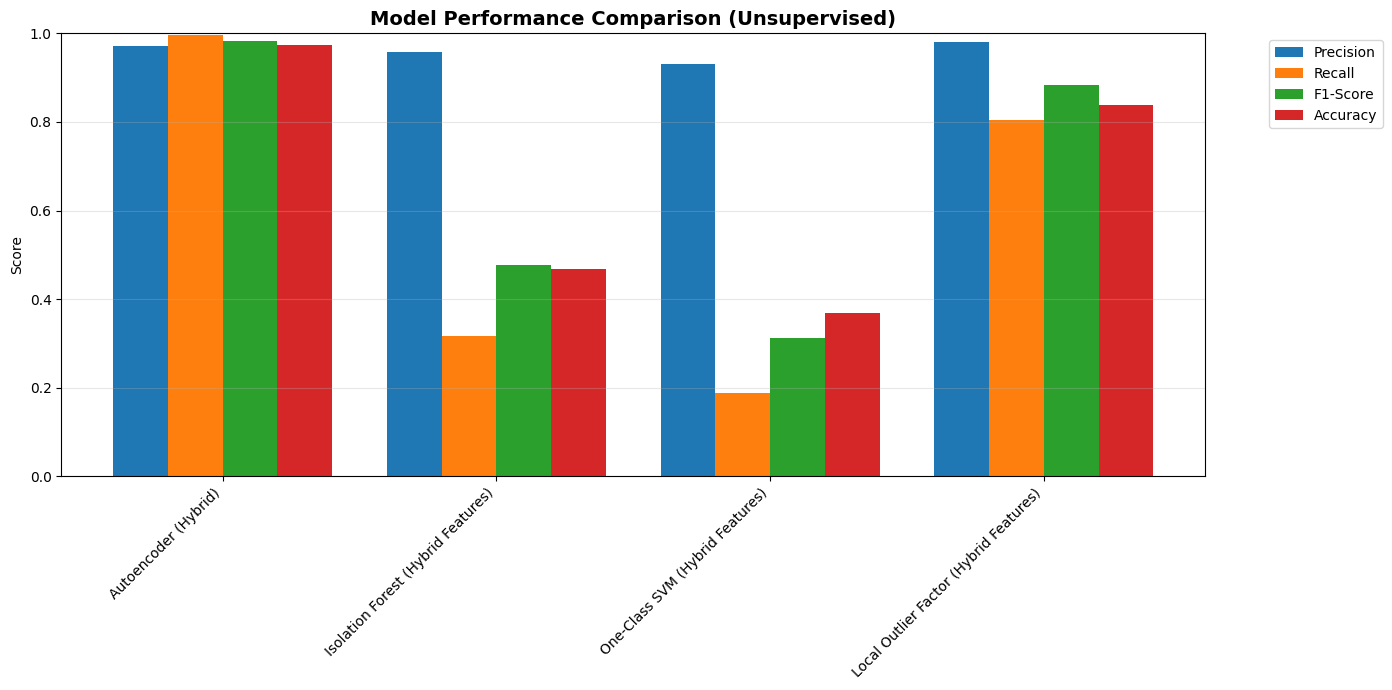


 BEST MODEL: Autoencoder (Hybrid) (F1: 0.9836)


In [ ]:


print("FINAL COMPARISON")


comparison_df = pd.DataFrame(results).round(4)
comparison_df = comparison_df.drop_duplicates(subset=['Model']).reset_index(drop=True) # Remove duplicate model entries
print(comparison_df.to_string(index=False))
comparison_df.to_csv('model_comparison_final.csv', index=False)

# Plot
plt.figure(figsize=(14, 7))
metrics = ['Precision', 'Recall', 'F1-Score', 'Accuracy']
x = range(len(comparison_df))
width = 0.2

for i, metric in enumerate(metrics):
    plt.bar([j + i*width for j in x], comparison_df[metric], width, label=metric)

plt.xticks([j + 1.5*width for j in x], comparison_df['Model'], rotation=45, ha='right')
plt.ylabel('Score')
plt.title('Model Performance Comparison (Unsupervised)', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('model_comparison_chart.png', dpi=300, bbox_inches='tight')
plt.show()

# Highlight winner
best_idx = comparison_df['F1-Score'].idxmax()
print(f"\n BEST MODEL: {comparison_df.loc[best_idx, 'Model']} (F1: {comparison_df.loc[best_idx, 'F1-Score']:.4f})")

# SUPPORTING EXPERIMENTS

### Experiment : Computational Efficiency Analysis

In [ ]:
import time
import sys
import tensorflow as tf
import os # Added for model size calculation
from tensorflow.keras.layers import Input, Dense # Added for model building functions
from tensorflow.keras.models import Model # Added for model building functions

# model_builder_fn should return an *uncompiled* Keras model, taking input_dim as argument
def evaluate_efficiency(model_builder_fn, X_train_data, X_test_data, epochs, batch_size):
    # Build a fresh model
    model = model_builder_fn(X_train_data.shape[1]) # Pass input_dim to builder

    # Compile the model
    model.compile(optimizer='adam', loss='mse')

    # Measure Training Time
    start_time = time.time()
    model.fit(X_train_data, X_train_data, epochs=epochs, batch_size=batch_size, verbose=0)
    training_time = time.time() - start_time

    # Measure Inference Time
    start_time = time.time()
    model.predict(X_test_data, verbose=0)
    inference_time = time.time() - start_time
    inference_per_sample = (inference_time / X_test_data.shape[0]) * 1000 # in ms

    # Model Parameters
    trainable_params = model.count_params()

    # Model Size (approximate by saving and loading)
    try:
        model_size_path = "temp_model_size.h5"
        tf.keras.models.save_model(model, model_size_path)
        model_size_bytes = os.path.getsize(model_size_path)
        model_size_mb = model_size_bytes / (1024 * 1024)
        os.remove(model_size_path) # Clean up
    except Exception as e:
        model_size_mb = np.nan # Unable to determine model size
        print(f"Warning: Could not get model size: {e}")


    return {
        'Training Time (s)': training_time,
        'Total Inference Time (s)': inference_time,
        'Inference per Sample (ms)': inference_per_sample,
        'Trainable Parameters': trainable_params,
        'Model Size (MB)': model_size_mb
    }

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split # Required for consistent data splitting


print(" COMPUTATIONAL EFFICIENCY ANALYSIS")



def build_hybrid_autoencoder_model_for_efficiency(input_dim):
    inp = Input(shape=(input_dim,))
    x = Dense(32, activation='relu')(inp)
    x = Dense(16, activation='relu')(x)
    x = Dense(32, activation='relu')(x)
    out = Dense(input_dim, activation='linear')(x)
    model = Model(inp, out)
    return model


def build_full_feature_autoencoder_model_for_efficiency(input_dim):
    input_layer = Input(shape=(input_dim,))
    encoded = Dense(64, activation="relu")(input_layer)
    encoded = Dense(32, activation="relu")(encoded)
    encoded = Dense(16, activation="relu")(encoded)
    decoded = Dense(32, activation="relu")(encoded)
    decoded = Dense(64, activation="relu")(decoded)
    decoded = Dense(input_dim, activation="linear")(decoded)
    return Model(inputs=input_layer, outputs=decoded)

#  Hybrid Autoencoder Data Preparation
if 'final_features' not in globals() or \
   'X_train' not in globals() or \
   'X_test' not in globals() or \
   'y_train' not in globals():
    raise ValueError("Required data for Hybrid AE efficiency (final_features, X_train, X_test, y_train) not found. Please ensure the 'Hybrid Approach' cell (3LHeRNqbIbQ7) is run before this cell.")

# Prepare the data consistent with the Hybrid Autoencoder's training
X_train_hybrid_filtered = X_train[final_features]
X_test_hybrid = X_test[final_features]

# Create the normal-only training set for the autoencoder, including the validation split logic
X_norm_hybrid = X_train_hybrid_filtered[y_train == 0]
X_val_temp_hybrid = X_norm_hybrid.sample(frac=0.2, random_state=42) # Consistent random_state with 3LHeRNqbIbQ7
X_train_final_hybrid = X_norm_hybrid.drop(X_val_temp_hybrid.index)

#  Full Feature Autoencoder Data Preparation
if 'X_train_final_full' not in globals() or \
   'X_test_full' not in globals():
    raise ValueError("Required data for Full Feature AE efficiency (X_train_final_full, X_test_full) not found. Please ensure the 'FULL FEATURE AUTOENCODER' cell (aaenL-982Gyw) is run before this cell.")

# Check if evaluate_efficiency function is defined. It should be from cell 'a00f9188'.
if 'evaluate_efficiency' not in globals():
     raise NameError("The 'evaluate_efficiency' function is not found. Please ensure cell 'a00f9188' is run first.")

# Evaluate Hybrid Autoencoder's efficiency
hybrid_efficiency_results = evaluate_efficiency(
    build_hybrid_autoencoder_model_for_efficiency,
    X_train_final_hybrid,
    X_test_hybrid,
    epochs=20, # Consistent with hybrid autoencoder training in 3LHeRNqbIbQ7
    batch_size=64
)
hybrid_efficiency_results['Model'] = 'Hybrid Autoencoder'

# Evaluate Full Feature Autoencoder's efficiency
full_efficiency_results = evaluate_efficiency(
    build_full_feature_autoencoder_model_for_efficiency,
    X_train_final_full,
    X_test_full,
    epochs=30, # Consistent with full feature autoencoder training in aaenL-982Gyw
    batch_size=64
)
full_efficiency_results['Model'] = 'Full Feature Autoencoder'

# Combine results into a DataFrame and display
efficiency_df = pd.DataFrame([hybrid_efficiency_results, full_efficiency_results])
print("\nComputational Efficiency Comparison:")
display(efficiency_df.set_index('Model').round(4))

 COMPUTATIONAL EFFICIENCY ANALYSIS



Computational Efficiency Comparison:


,Training Time (s),Total Inference Time (s),Inference per Sample (ms),Trainable Parameters,Model Size (MB)
Model,,,,,
Hybrid Autoencoder,23.1498,1.9082,0.0452,1494,0.0488
Full Feature Autoencoder,40.3980,3.2537,0.0771,10746,0.1663


### Experiment : Attack-Type Performance Analysis

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split

print(" ATTACK-TYPE PERFORMANCE ANALYSIS")




if 'final_features' not in globals() or \
   'X_train' not in globals() or \
   'X_test' not in globals() or \
   'y_train' not in globals():
    raise ValueError("Required data (final_features, X_train, X_test, y_train) for re-creating hybrid model not found.")

X_tr_hybrid_rebuild = X_train[final_features]
# X_test_hybrid is derived from X_test[final_features] and available later.

X_norm_hybrid_rebuild = X_tr_hybrid_rebuild[y_train == 0]
X_val_hybrid_rebuild = X_norm_hybrid_rebuild.sample(frac=0.2, random_state=42) # Consistent random_state with 3LHeRNqbIbQ7
X_tr_final_hybrid_rebuild = X_norm_hybrid_rebuild.drop(X_val_hybrid_rebuild.index)

# Build Model - structure must match the final hybrid autoencoder from cell 3LHeRNqbIbQ7
input_dim_hybrid = X_tr_final_hybrid_rebuild.shape[1]
inp_hybrid = Input(shape=(input_dim_hybrid,))
x_hybrid = Dense(32, activation='relu')(inp_hybrid)
x_hybrid = Dense(16, activation='relu')(x_hybrid)
x_hybrid = Dense(32, activation='relu')(x_hybrid)
out_hybrid = Dense(input_dim_hybrid, activation='linear')(x_hybrid)

hybrid_autoencoder = Model(inp_hybrid, out_hybrid)
hybrid_autoencoder.compile(optimizer='adam', loss='mse')

# Train - use same epochs and batch_size as in 3LHeRNqbIbQ7
hybrid_autoencoder.fit(X_tr_final_hybrid_rebuild, X_tr_final_hybrid_rebuild,
                    epochs=20, batch_size=64,
                    validation_data=(X_val_hybrid_rebuild, X_val_hybrid_rebuild),
                    verbose=0)

# Calculate Threshold - use same percentile as in 3LHeRNqbIbQ7
val_pred_hybrid = hybrid_autoencoder.predict(X_val_hybrid_rebuild, verbose=0)
val_mse_hybrid = np.mean(np.power(X_val_hybrid_rebuild - val_pred_hybrid, 2), axis=1)
threshold_hybrid = np.percentile(val_mse_hybrid, 85)


#  Define evaluate_by_attack_type function
def evaluate_by_attack_type(model, X_test_data, y_test_data, attack_type_labels, threshold):
    results_list = []

    # Ensure X_test_data and attack_type_labels have consistent indices
    X_test_data_indexed = X_test_data.reset_index(drop=True)
    attack_type_labels_indexed = attack_type_labels.reset_index(drop=True)
    y_test_data_indexed = y_test_data.reset_index(drop=True)

    # Get reconstruction errors for the entire test set
    test_recon = model.predict(X_test_data_indexed, verbose=0)
    test_mse = np.mean(np.power(X_test_data_indexed - test_recon, 2), axis=1)
    y_pred = (test_mse > threshold).astype(int)

    all_attack_types = attack_type_labels_indexed[y_test_data_indexed == 1].unique()

    # Evaluate performance for normal traffic (label == 0)
    normal_mask = (y_test_data_indexed == 0)
    normal_y_true = y_test_data_indexed[normal_mask]
    normal_y_pred = y_pred[normal_mask] # y_pred is already aligned with X_test_data_indexed

    # Calculate F1, Precision, Recall for normal class (pos_label=0)
    normal_f1 = f1_score(normal_y_true, normal_y_pred, pos_label=0, zero_division=0)
    normal_precision = precision_score(normal_y_true, normal_y_pred, pos_label=0, zero_division=0)
    normal_recall = recall_score(normal_y_true, normal_y_pred, pos_label=0, zero_division=0)

    results_list.append({
        'Attack Type': 'Normal Traffic',
        'Samples': len(normal_y_true),
        'F1-Score': normal_f1,
        'Precision': normal_precision,
        'Recall': normal_recall
    })

    # Evaluate performance for each specific attack type
    for atk_type in sorted(all_attack_types):
        # Samples that are attacks (y_test == 1) AND of the current attack type
        attack_mask = (y_test_data_indexed == 1) & (attack_type_labels_indexed == atk_type)

        y_true_atk = y_test_data_indexed[attack_mask]
        y_pred_atk = y_pred[attack_mask]

        if len(y_true_atk) > 0:
            f1 = f1_score(y_true_atk, y_pred_atk, pos_label=1, zero_division=0)
            precision = precision_score(y_true_atk, y_pred_atk, pos_label=1, zero_division=0)
            recall = recall_score(y_true_atk, y_pred_atk, pos_label=1, zero_division=0)
        else:
            f1, precision, recall = 0.0, 0.0, 0.0 # No samples, so metrics are 0

        results_list.append({
            'Attack Type': atk_type,
            'Samples': len(y_true_atk),
            'F1-Score': f1,
            'Precision': precision,
            'Recall': recall
        })

    return pd.DataFrame(results_list)



original_df_for_attack_types = pd.read_csv('train_test_network.csv')
original_df_for_attack_types = original_df_for_attack_types.replace('-', np.nan)

num_cols_raw = original_df_for_attack_types.select_dtypes(include=[np.number]).columns
original_df_for_attack_types[num_cols_raw] = original_df_for_attack_types[num_cols_raw].fillna(0)

for col in original_df_for_attack_types.select_dtypes(include='object').columns:
    if col not in ['label', 'type']:
        original_df_for_attack_types[col] = original_df_for_attack_types[col].fillna('unknown')

def port_category(p):
    if p <= 1023:   return 0
    elif p <= 49151: return 1
    else:            return 2

original_df_for_attack_types['dst_port'] = original_df_for_attack_types['dst_port'].apply(port_category)

X_orig = original_df_for_attack_types.drop(columns=['label', 'type'], errors='ignore')
y_orig = original_df_for_attack_types['label']
attack_types_orig = original_df_for_attack_types['type']

for col in X_orig.select_dtypes(include='object').columns:
    X_orig[col] = LabelEncoder().fit_transform(X_orig[col])

for col in X_orig.columns:
    X_orig[col] = X_orig[col].clip(
        X_orig[col].quantile(0.01),
        X_orig[col].quantile(0.99)
    )
scaler_full_orig = RobustScaler()
X_scaled_orig = pd.DataFrame(
    scaler_full_orig.fit_transform(X_orig), columns=X_orig.columns
)


_, _, _, _, _, attack_labels_test = train_test_split(
    X_scaled_orig, y_orig, attack_types_orig, test_size=0.2, random_state=42, stratify=y_orig
)

attack_performance_df = evaluate_by_attack_type(hybrid_autoencoder, X_test_hybrid, y_test, attack_labels_test, threshold_hybrid)
display(attack_performance_df)

 ATTACK-TYPE PERFORMANCE ANALYSIS


,Attack Type,Samples,F1-Score,Precision,Recall
0,Normal Traffic,10000,0.943476,1.0,0.893000
1,backdoor,4053,1.000000,1.0,1.000000
2,ddos,4004,0.995232,1.0,0.990509
3,dos,4117,0.980688,1.0,0.962108
4,injection,3900,0.999230,1.0,0.998462
5,mitm,209,0.992771,1.0,0.985646
6,password,3980,1.000000,1.0,1.000000
7,ransomware,3903,0.996400,1.0,0.992826
8,scanning,4041,1.000000,1.0,1.000000
9,xss,4002,0.999750,1.0,0.999500


### Experiment : Robustness Analysis

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
import random

print(" ROBUSTNESS ANALYSIS")



if 'X_train_final_hybrid' not in globals() or \
   'X_test_hybrid' not in globals() or \
   'y_test' not in globals() or \
   'final_features' not in globals():
    raise ValueError("Required data for robustness analysis not found. Please ensure relevant cells are run.")

#  function to build the autoencoder model for a given input dimension
def build_ae_model():
    input_dim = len(final_features)
    input_layer = Input(shape=(input_dim,))
    encoded = Dense(32, activation="relu")(input_layer)
    encoded = Dense(24, activation="relu")(encoded)
    encoded = Dense(16, activation="relu")(encoded)
    decoded = Dense(24, activation="relu")(encoded)
    decoded = Dense(32, activation="relu")(decoded)
    decoded = Dense(input_dim, activation="linear")(decoded)
    model = Model(inputs=input_layer, outputs=decoded)
    model.compile(optimizer='adam', loss='mse')
    return model

# function to calculate the threshold
def calculate_threshold(model_instance, X_data):
    recon = model_instance.predict(X_data, verbose=0)
    mse = np.mean(np.power(X_data - recon, 2), axis=1)
    threshold = np.percentile(mse, 85)
    return threshold

def robustness_test(model_builder, X_train_data, X_test_data, y_test_labels, threshold_calculator, seeds, epochs=20, batch_size=64):
    results = []
    for seed in seeds:
        # Set random seeds for reproducibility
        random.seed(seed)
        np.random.seed(seed)
        tf.random.set_seed(seed)

        # Build and train model
        model = model_builder()
        # X_train_data is already normal-only and pre-split for training
        X_val_robust = X_train_data.sample(frac=0.2, random_state=seed)
        X_train_robust = X_train_data.drop(X_val_robust.index)

        model.fit(
            X_train_robust, X_train_robust,
            epochs=epochs, batch_size=batch_size,
            validation_data=(X_val_robust, X_val_robust),
            shuffle=True, verbose=0
        )

        # Calculate threshold
        threshold = threshold_calculator(model, X_val_robust)

        # Evaluate on test set
        test_recon = model.predict(X_test_data, verbose=0)
        test_mse = np.mean(np.power(X_test_data - test_recon, 2), axis=1)
        y_pred = (test_mse > threshold).astype(int)

        # Store metrics
        f1 = f1_score(y_test_labels, y_pred)
        precision = precision_score(y_test_labels, y_pred)
        recall = recall_score(y_test_labels, y_pred)
        accuracy = accuracy_score(y_test_labels, y_pred)

        results.append({
            'Seed': seed,
            'F1-Score': f1,
            'Precision': precision,
            'Recall': recall,
            'Accuracy': accuracy,
            'Threshold': threshold
        })

    results_df = pd.DataFrame(results)
    summary_df = results_df.drop(columns=['Seed', 'Threshold']).agg(['mean', 'std']).T
    return results_df, summary_df


robustness_df, robustness_summary = robustness_test(
    build_ae_model,
    X_train_final_hybrid,
    X_test_hybrid,
    y_test,
    calculate_threshold,
    seeds=[42, 7, 21, 99, 123, 100, 200, 300, 400, 500]
)

print("Robustness Test Results:")
display(robustness_df)
print("\nRobustness Summary (F1-Score):")
display(robustness_summary)

 ROBUSTNESS ANALYSIS
Robustness Test Results:


,Seed,F1-Score,Precision,Recall,Accuracy,Threshold
0,42,0.966029,0.969305,0.962774,0.948329,0.000688
1,7,0.928004,0.986812,0.875811,0.896302,0.001719
2,21,0.976160,0.958249,0.994753,0.962923,0.000155
3,99,0.976690,0.958264,0.995840,0.963728,0.000234
4,123,0.965697,0.955729,0.975876,0.947097,0.000236
5,100,0.797463,0.977598,0.673383,0.738989,0.004508
6,200,0.975647,0.956400,0.995684,0.962070,0.000336
7,300,0.880998,0.979230,0.800677,0.834940,0.001763
8,400,0.871882,0.982824,0.783446,0.824303,0.002619
9,500,0.957888,0.976888,0.939613,0.936957,0.000785



Robustness Summary (F1-Score):


,mean,std
F1-Score,0.929646,0.060638
Precision,0.970130,0.012029
Recall,0.899786,0.112534
Accuracy,0.901564,0.077222
